In [1]:
!pwd

/Users/thomasmyles/dev/neural-networks


link to video: https://x.com/neil_xbt/status/2047512855155528054?s=12

What we will do:
- Define a neural network
- Train the neural network

micrograd:
- https://github.com/karpathy/micrograd
- repo he put on github a few years ago
- what is micrograd?
    - autograd engine for neural networks
    - "it implements backpropagation"
    - backpropagation: allows you to efficiently compute the gradient of some kind of loss function, with respect to the weights of the neural network
    - "therefore, we increase the accuracy of the neural network"
    - at mathematical core of any neural network training network ie. JAX, PyTorch, TensorFlow, etc.

example usage:

```python
-- Slightly contrived example, showing a number of possible supported operations
from micrograd.engine import Value

# Overall: building out expression graph
# input: a/b
# output: g

# (micrograd builds out the mathemtical expression graph)

# 2 inputs: a and b
# we wrap those values in Value() objects, which wraps the numbers
# they get transformed
a = Value(-4.0)
b = Value(2.0)

c = a + b # child nodes of c: a / b
d = a * b + b**3
c += c + 1
c += 1 + c + (-a)
d += d * 2 + (b + a).relu()
d += 3 * d + (b - a).relu()
e = c - d
f = e**2
g = f / 2.0
g += 10.0 / f
print(f'{g.data:.4f}') # prints 24.7041, the outcome of this forward pass

# "not only can we do a forward pass, where output is g ie. 24.7041, but we can also call .backward()
# "initaliazes backpropagation at node g"
# to compute the gradient of g with respect to a and b
# "will start at g, go backwards, and recursively apply the chain rule from calculus"
# what this lets us do: evaluate the derivate of g, with respect to internal nodes (e/d/c) and input nodes (a/b)
# then: we can query this derivative with respone to a, or b, (138 / 645 below)
g.backward()
print(f'{a.grad:.4f}') # prints 138.8338, i.e. the numerical value of dg/da
print(f'{b.grad:.4f}') # prints 645.5773, i.e. the numerical value of dg/db

# why this is important:
# - tells us how a/b are affecting g, through this mathematical expression
# - a.grad being 138: if we slighlty make a larger, g will get larger by 138 (ie. slope of +138)
# - b.grad being 645: if we slighlty make b larger, g will get larger by 645 (ie. slope of +645)

# note: this specific expression is completely meaningless, but it's a simple example to show how backpropagation works (flexes the operations that micrograd supports)
# - neural networks are just like this one, but less crazy actually

```

neural network: mathemtical expression (just a certain class)
- take input data
- take weights of a neural network
- output: predictions of neural net OR loss function

reminder: backpropogation is more general - does not care about neurl networks, just cases about arbitrary mathemtical expressions
- we use this to machinery train neural networks

one more note - micrograd is scalar value autograd engine
- example: -4.0, 2.0
- allows us to not have to deal with n-dimensional tensors in many NN libraries
- training bigger networks: need to use these tensors
    - none of math changes, just dont for efficiency
    - what they do:
        - take scalar values
        - package up into tensors
            - "a race of these scalars"
        - make operations on large arrays
            - takes advantage of parallelism on a CPU (so it runs faster)

this is why he wrote micrograd...
- understand how things work at a mental
- THEN later, you can speed it up
- "my claim: micrograd is all you need to train neural networks, and everything else is efficiency"
    - you may think micrograd is very compolicated code then, but it is not

2 files
- engine.py: actual backpropogation, giving power to neural networks, is 100 lines of code
- nn.py: NN library, built on top of autograd engine
    - 3 things defined:
        - Neuron
        - Layer of Neurons
        - MultiLayer Perceptron (sequence of layers)

"it is just a total joke! lots of power from 150 lines of code"

diving right into implementing micrograd, step by step



In [2]:
# starts coding in notebook...

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# he defines this function randomly ...
# "takes scalar value x, returns scalar value y"
def f(x):
    return 3*x**2 - 4*x + 5

In [5]:
# test it out
f(3.0)

20.0

In [6]:
# we can also plot this function, to get a sense of its shape...
# - this is a parabola/quadratic

xs:
[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]

ys:
[100.      91.6875  83.75    76.1875  69.      62.1875  55.75    49.6875
  44.      38.6875  33.75    29.1875  25.      21.1875  17.75    14.6875
  12.       9.6875   7.75     6.1875   5.       4.1875   3.75     3.6875
   4.       4.6875   5.75     7.1875   9.      11.1875  13.75    16.6875
  20.      23.6875  27.75    32.1875  37.      42.1875  47.75    53.6875]


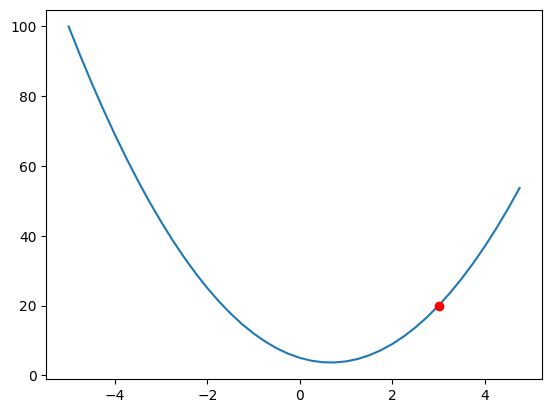

In [7]:
# feed in scalar values
xs = np.arange(-5, 5, 0.25)
print("xs:")
print(xs)

ys = f(xs)
print("\nys:")
print(ys)

plt.plot(xs, ys)
# add a line for where x = 3, y = 20
plt.plot([3], [f(3)], 'ro')
plt.show()

next - what is the derivative of this function, at any point x ?
- process:
    - take mathematical expression
    - apply product rule
    - plug in diff x's, see what derivative is
        - we are NOT going to do this
            - nobody in neural networks wrties this out (nobody derives the derivative!)

- instead of taking "symbolic" approach... we will look at the definition or deriviate, and see if we understand what it is measuring
- derivative: limit as h -> 0
    - "if you slightly bump up `x` by small number `h`, how does the funciton respond (ie. what is the slope)

In [8]:
# evaluating the derivative numerically 
h = 0.001 # take very small h (defn of derivative takes it to 0)
x = 3.0 # if we nudge x in a small direction, 
print(f(x + h))

print("if we slightly go positively, the function will slightly go positively")

20.014003000000002
if we slightly go positively, the function will slightly go positively


In [9]:
# strength/szie of slope ie. how much the function responded
# (this is the numerical approximation of the slope)
print((f(x + h) - f(x)) / h) # rise over run!


14.00300000000243


In [10]:
# we have to make h VERY VERY small, to make it converge to the "exact" amount
h = 0.00000001
x = 3.0
print(f(x + h))
print((f(x + h) - f(x)) / h)

20.00000014
14.00000009255109


In [11]:
# note: because we are using floating point arithmetic, if you use too many 0's, you will get into trouble (ie. incorrect answer)
# representations of numbers in compouter memory are finite ...
h = 0.000000000000000000000000000000000000000000000000000000000000000000000000000000001
x = 3.0
print(f(x + h))
print((f(x + h) - f(x)) / h)


20.0
0.0


when x = 3; Slope is 14.

In [12]:
# what about when slope is -3 ...

In [13]:
h = 0.00000001
x = -3.0 # number is negative , so we will go below 20
print(f(x + h))
print((f(x + h) - f(x)) / h)

43.999999779999996
-22.00000039920269


In [14]:
h = 0.00000001
x = 2/3 # this makes the slope 0 (he had to look this up) [at this precise point, the derivative is 0 ie. if we nudge in positive direction, it does not change]
print(f(x + h))
print((f(x + h) - f(x)) / h)

3.666666666666667
0.0


In [15]:
# time to get more complex ...

In [16]:
# 3 scalar inputs into "expression graph"
a = 2.0
b = -3.0
c = 10.0

# single output d
d = a*b + c
print(d)


4.0


In [17]:
# let's look at deriviate, in respect of a/b/c

In [18]:
# a:

In [19]:
h = 0.0001

# input
a = 2.0
b = -3.0
c = 10.0

# derivative of d, with respect to a
d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1) # 4, see above
print('d2', d2) # b is negative, so if a is slightly more positive, the final result 'd' will be slightly less positive than 4
print('slope', (d2 - d1) / h) # d2 - d1 is how much function increased when we bumped the specific input by h (tiny amount), normlaized by h , to get the slope!

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


note: -3 is right answer mathematically, too
- differentiating: a*b + c, with respect to a:
    - a -> 1
    - b -> b
    - c is cosntant -> 0
    - result: b
- if you take derivates, you end up with b, which is -3

In [20]:
# b

In [21]:
h = 0.0001

# input
a = 2.0
b = -3.0
c = 10.0

# derivative of d, with respect to a
d1 = a*b + c
b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h) # a is poositive, so bumping b will raise it by a=2

d1 4.0
d2 4.0002
slope 2.0000000000042206


note: 
- differentiating a*b + c, with respect to b:
    - a -> a
    - b -> 1
    - c is constant -> 0
    - result: a, which is 2
    

In [22]:
# c

In [23]:
h = 0.0001

# input
a = 2.0
b = -3.0
c = 10.0

# derivative of d, with respect to a
d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h) # a is poositive, so bumping b will raise it by a=2

d1 4.0
d2 4.0001
slope 0.9999999999976694


note: 
- differentiating a*b + c, with respect to b:
    - a -> 1
    - b -> 1
    - c is constant -> stays constant (1)
    - result: 1
        - you are just adding to c...
    

# we now have intuitive sense of what the derivatives are doing / telling us about the function ... onto neural networks!


- neural networks: massive mathematical expressions
    - need data structures to maintain these expressions
    - how: build out Value() object

In [24]:
class Value:
    def __init__(self, data):
        self.data = data

    def __repr__(self):
        return f"Value(data={self.data})"

a = Value(2.0)
b = Value(-3.0)
# a + b

In [25]:
# have to teach it how to add ... or you get error: TypeError: unsupported operand type(s) for +: 'Value' and 'Value'

In [26]:
# double underscore methods: operators 

In [27]:
class Value:
    def __init__(self, data):
        self.data = data

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data) # we return a new Value object, with the sum of the two data values

a = Value(2.0)
b = Value(-3.0)
a + b

Value(data=-1.0)

In [28]:
a.__add__(b) # floating point + addition

Value(data=-1.0)

In [29]:
# now implement multiply ...
class Value:
    def __init__(self, data):
        self.data = data

    # def __repr__(self):
        # return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data)

    def __mul__(self, other):
        return Value(self.data * other.data)
    
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)

d = a*b + c
d



In [30]:
# ^what you get without __repr__ ^

In [31]:
# now implement multiply ...
class Value:
    def __init__(self, data):
        self.data = data

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data)

    def __mul__(self, other):
        return Value(self.data * other.data)
    
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)

d = a*b + c
d



Value(data=4.0)

In [32]:
(a.__mul__(b)).__add__(c)

Value(data=4.0)

what we are missing: the "connective tissue" of the expression
- need to keep expressions graphs
    - "we need to keep pointers of which values, used other values"

In [33]:
# what we are adding now: children
class Value:
    def __init__(self, data, _children=()): # not sure why it is tuple here but set in the class, - he says it was prob for "efficiency"
        self.data = data
        self._prev = set(_children) # starts as empty set

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other)) # need to "feed in" the children of this value

    def __mul__(self, other):
        return Value(self.data * other.data) # other is the child of self
    
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)

d = a*b + c
print(d)

Value(data=4.0)


In [34]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [35]:
# easier one ...

In [36]:
a = Value(2.0)
b = Value(-3.0)
# c = Value(10.0)

d = a*b# + c
print(d)

Value(data=-6.0)


In [37]:
d._prev

set()

now: we know:
- the children

what we don't know:
- what operation created this value

In [38]:
# add in operation

In [39]:
class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')

    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')

a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)

d = a*b + c
print(d)

Value(data=4.0)


In [40]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [41]:
d._op

'+'

In [42]:
"we now have the full mathemtical expression"

'we now have the full mathemtical expression'

In [43]:
...

Ellipsis

expressions are about to get quite a bit larger... we want to be able to visualize them!

copy paste this code:
- what it does: visualizes the expression graphs
    - creates draw_dot()
    - viz's it


graphviz open source api: https://graphviz.org

In [44]:
import os
os.environ["PATH"] += ":/opt/homebrew/bin"

In [45]:
!brew --version
!dot -V

Homebrew 5.1.10
dot - graphviz version 14.1.5 (20260411.2331)


In [46]:
!brew --version

Homebrew 5.1.10


In [47]:
!dot -V

dot - graphviz version 14.1.5 (20260411.2331)


In [48]:
!pip install graphviz


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


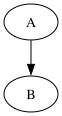

In [49]:
# test for graphviz working ...
from graphviz import Digraph

dot = Digraph()
dot.node('A')
dot.node('B')
dot.edge('A', 'B')
dot

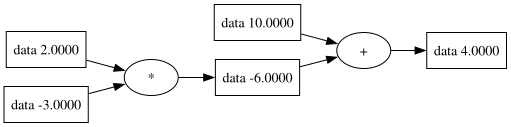

In [50]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ data %.4f }" % (n.data,), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

draw_dot(d)

note:
- boxes: nodes
- circles: operators

In [51]:
# add labels ...

In [52]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')

    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

d = a*b + c
print(d)

Value(data=4.0)


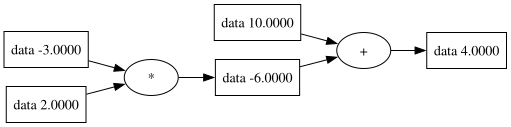

In [53]:
draw_dot(d)

In [54]:
... # ok

Ellipsis

In [55]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

e = a*b; e.label = 'e' # added a new node ...
d = e+c; d.label = 'd'
print(d)

Value(data=4.0)


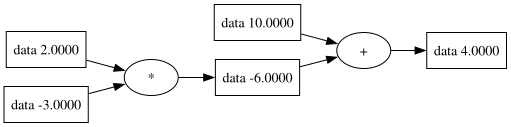

In [56]:
draw_dot(d)

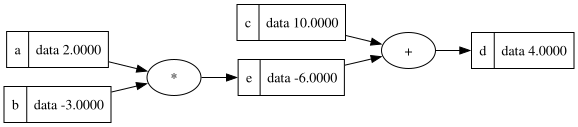

In [57]:
# ADDING TO THE draw_dot() function ...

from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f }" % (n.label, n.data,), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

draw_dot(d)

In [58]:
# finally, let's make the expression 1 layer deeper
# - "after d, we will make 1 value object named F" (-2.10)
# - "L is the output of our graph"
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

e = a*b; e.label = 'e'
d = e+c; d.label = 'd'

f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

L

Value(data=-8.0)

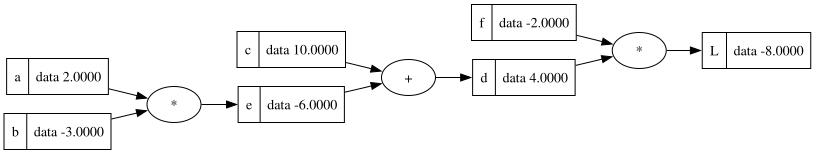

In [59]:
draw_dot(L)

In [60]:
# answer: L = -8.0

note: we are at 29:00 in the video on X

recap of what we have done so far:
- build out math expressions using + and * 
- scalar valued
- we do a "forward pass" to build out the math expression
    - multiple inputs
    - single output (L = -8)

what to do next: backpropogation
- start at the end (L = -8)
- calculate gradient at each individual value
    - for each:
        - calculate gradient, with respect to L
            - example: derivative of L w/ respect to L: 1
            - example: derivative of L w/ respect to E: ...
            - ...
            - example: derivative of L w/ respect to A: ...

- what we are interested in: derivative of the loss function, with respect to weights of the neural network
    - some inputs will represent weight of the neural net
    - "derivative of the output, with respect to some of the leaf nodes"
        - data is fixed
        - weights will be iterated on, based on gradient information


...

next
- create variable inside Value() class that maintains the derivate of L, with respect to that value
    - what we will call it: grad
        - init at 0.0, because we assume each value has no effect on the output (if gradient is 0, the slope/gradient does not affect the loss function)

In [61]:

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')

    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')

# a = Value(2.0, label='a')
# b = Value(-3.0, label='b')
# c = Value(10.0, label='c')

# d = a*b + c
# print(d)
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e+c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

L

Value(data=-8.0)

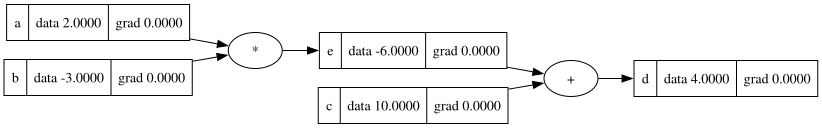

In [62]:
# ADDING TO THE draw_dot() function ... (grad)

from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

draw_dot(d)

In [63]:
# all grads are initialized to 0.0 ...

In [64]:
# reminder: grad is the derivative of the loss function/output, with respect to the value

In [65]:
# let's fill in the gradients!

In [66]:
# first: fill in the grad for L
def lol():
    # gating function: don't want to mess up the global scope
    # "Little staging area"

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L1 = L.data # make sure to grab the data, not the object

    a = Value(2.0 + h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L2 = L.data

    print((L2 - L1) / h) # rise, over run

lol() # derivative of L w/ respect to A is 6

6.000000000021544


In [67]:
def lol():
    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L1 = L.data # make sure to grab the data, not the object

    # a = Value(2.0 + h, label='a')
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    # L2 = L.data
    L2 = L.data + h

    print((L2 - L1) / h)

lol() # derivative of L w/ respect to L is 1

0.9999999999976694


In [68]:
# dL/dL = 1

In [69]:
# this is kind of like the base case ^

In [70]:
# manually set L.grad to 1 (manual backpropogation)
L.grad = 1.0



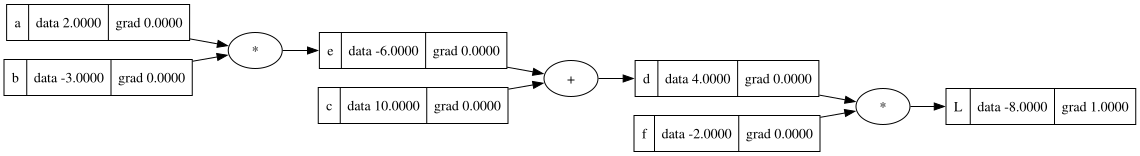

In [71]:
draw_dot(L)

In [72]:
# next, we have to do D and D

In [73]:
# d

L = d * f
- 4 * -2 = -8 (TRUE)

dL/dd = f

derive it ...
- derivative defn: (f(x+h) - f(x)) / h
    - as limit as h -> 0


= ((d+h) * f - d*f/h)
= (d*f + h*f - d*f)/h
= h*f / h
= f

"limit as h -> 0, we get f"

In [74]:
f.grad = 4.0 # d.data

In [75]:
...

Ellipsis

In [76]:
# f

In [77]:
d.grad = -2.0 # L=d*f, so d=L/f ie. d=-8/4 = -2

In [78]:
...

Ellipsis

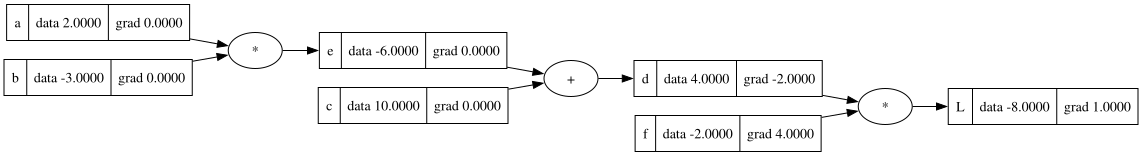

In [79]:
draw_dot(L)

In [80]:
# let's make sure d and f are correct ...

In [81]:
def lol():
    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0 + h, label='f')
    L = d * f; L.label = 'L'

    L2 = L.data

    print((L2 - L1) / h)

lol() # should get 4, for F's grad

3.9999999999995595


In [82]:
def lol():
    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    # d = (e+c) + h; d.label = 'd'
    d = e+c; d.label = 'd'
    d.data += h # why we do it this way: 
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L2 = L.data

    print((L2 - L1) / h)

lol() # should get -2, for D's grad

-1.9999999999953388


"in-line gradient check"
- gradient check: deriving backpropogation, get it in respect to the others
- numerical gradient: estimating using small step-size



next - crux of backpropogation
- MOST important node to understand
    - "if you understand the gradient for this node, you will understand all of backpropogation, and training of neural nets"

what we need to do: dL / dc (derivative L, with respect to c)
- problem: how to do Dl / dc, when they are not connected?
    - c -> d/f -> L

- what we know now:
    - how D impacts L ie. how sensitive L is to D (grad: -2)
    - how C impacts D (grad: 0)

- what we do NOT know:
    - how C impacts L ie. how sensitive L is to C (???)
        - "if we wiggle C, how does that impact L, through D?"

- how to put that information together: chain rule !
    - dd / dc
    - 
    - 

"local derivative of a sum expression is very simple"
- local derivative, meaning:
    - we hve final vlaue at end of graph
    - we are small node here
    - plus node knows nothing about the rest of the graph
        - it took a C and E, made D


- "we don't want the local derivative"

- + node is embedded in a big graph

back to the chain rule ...

h'(x)

if variable z depends on variable y, which itself depends on variable x, then z depends on x as well

(dz/dx) = (dz/dy)_y(x) * (dy/dx)_x

## Intuitive explanation

Intuitively, the chain rule states that knowing the instantaneous rate of change of $z$ relative to $y$ and that of $y$ relative to $x$ allows one to calculate the instantaneous rate of change of $z$ relative to $x$ as the product of the two rates of change.

As put by George F. Simmons:  
*"if a car travels twice as fast as a bicycle and the bicycle is four times as fast as a walking man, then the car travels $2 \times 4 = 8$ times as fast as the man."*

The relationship between this example and the chain rule is as follows. Let $z$, $y$, and $x$ be the (variable) positions of the car, the bicycle, and the walking man, respectively.

$$
\frac{dz}{dy} = 2
$$

Similarly,

$$
\frac{dy}{dx} = 4
$$

So, the rate of change of the relative positions of the car and the walking man is:

$$
\frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx} = 2 \cdot 4 = 8
$$

The rate of change of positions is the ratio of the speeds, and the speed is the derivative of the position with respect to time:

$$
\frac{dz}{dx} = \frac{\frac{dz}{dt}}{\frac{dx}{dt}}
$$

or, equivalently,

$$
\frac{dz}{dt} = \frac{dz}{dx} \cdot \frac{dx}{dt}
$$

which is also an application of the chain rule.

problem: how to do dL / dc?
- we know L is sensitive to d, but how is it sensitive to C?
    - ...

what we do: take the intermediate rates of change, multiply them together!

"+ node routes the gradients"

In [83]:
c.grad = -2.0
e.grad = -2.0

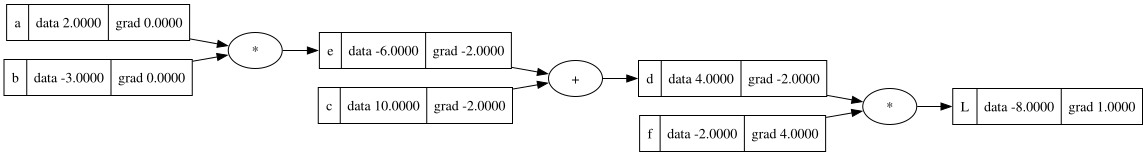

In [84]:
draw_dot(L)

"backprogating signal, you can imagine it flowing backwards through the graph"
"the plus sign is the leaf node, gives same value to both"

In [85]:
# verify with code / approximation

def lol():
    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    c.data += h # add this !
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L2 = L.data

    print((L2 - L1) / h)

lol() # should get -2, for c ie. dL/dc


-1.9999999999953388


In [86]:
# verify with code / approximation

def lol():
    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    # c.data += h # add this !
    e = a*b; e.label = 'e'
    e.data += h
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L2 = L.data

    print((L2 - L1) / h)

lol() # get the same for e ie dL/de


-1.9999999999953388


now that we found derivatives of internal nodes, we will recurse again

my guess on what we will do
- dL / da
- dL / db

what Andrej says we will do:
- apply chain rule again
    - dL / da, or (dL / de) * (de / da)
    - dL / db, or (dL / de) * (de / db)

In [87]:
def lol():
    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L1 = L.data

    a = Value(2.0, label='a')
    a.data += h
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L2 = L.data

    print((L2 - L1) / h)

lol() # a

6.000000000021544


In [88]:
def lol():
    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L1 = L.data

    a = Value(2.0, label='a')
    # a.data += h
    b = Value(-3.0, label='b')
    b.data += h
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L2 = L.data

    print((L2 - L1) / h)

lol() # b

-4.000000000008441


In [89]:
# these are NOT the same.... is it bc we are using * instead of + ???
# - update: correct values, just not the same ... idk why yet

In [90]:
# 

In [91]:
# a.grad = (dL / de) * (de / da)
a.grad = (-2.0 * -3.0) # -3 comes from b, ie. its a constant already

# b.grad = (dL / de) * (de / db)
b.grad = (-2.0 * 2.0) # 2 comes from a, ie. its a constant already




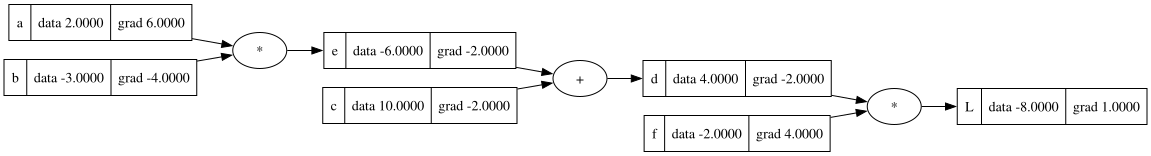

In [92]:
draw_dot(L)

manual backpropogation is done!

what we did:
- iterate thru nodes
- locally apply chain rule
- look how output was produced
    - we have pointers to children nodes
- recursively multiply local derivates 


that's all it is!
backpropogation: recursive application of chain rule, backwards, through the computational graph!

---

(at 51min in video)

what we are doing now: nudge our inputs to try and make L go up
- in particular: go in the direction of the gradient
    - example: a=2 is a positive constant, could bump that to 3 (we will do some small step amount...)

In [93]:
step_size = 0.01

a.data += a.grad * step_size # why it is data += grad * step_size: ...
b.data += b.grad * step_size
c.data += c.grad * step_size
f.data += f.grad * step_size

# these are the leaf nodes, which we have control over ! (e,d, and L are not leaf nodes ie. are a product/sum of other nodes)

In [94]:
# re-run the forward pass ...
# a = Value(2.0, label='a')
# b = Value(-3.0, label='b')
# c = Value(10.0, label='c')
# f = Value(-2.0, label='f')

e = a*b#; e.label = 'e'
d = e+c#; d.label = 'd'
# f = Value(-2.0, label='f')
L = d * f#; L.label = 'L'

print(L.data)

-7.286496


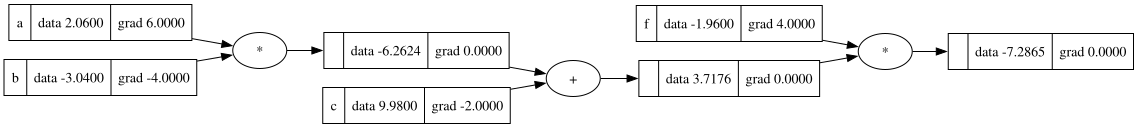

In [95]:
draw_dot(L)

"this is one step of an optimization that we end up running"

- this gradient: just gives us some power, we know how to influence the outcome
    - very useful for training neural nets

---
more useful example: backpropogate through a neuron

simple case: multilayer perceptrons
- 1 input layer
- 2 hiddens layer
    - neurons fully connected to each other
- 1 output layer

what we have:
- inputs: x's
- synapses: w/weights
- output: cell body
    - what flows: w*x (many of these flowing to the cell body)

basiallym we are...
- taking the w*x of all inputs
- adding the bias
- put it thru an activation function
    - activation function: usually some sort of "squashing" function ie tan-h, sigmoid


In [96]:
# using tan-h here...

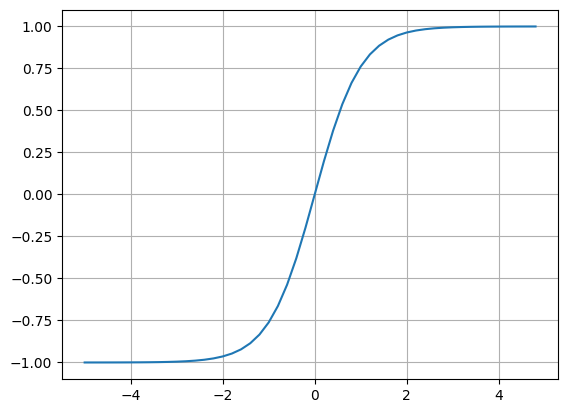

In [97]:
# as inputs come in, they are squashed at the y coordinate
# - at 0: you get 0
# - at -100: you get -1
# - at +100000: you get 1

xs = np.arange(-5,5,0.2)
ys = np.tanh(xs)
plt.plot(xs,ys);plt.grid();



what comes out of this neuron: activation applied to dot product of the weights + inputs

In [98]:
# let's write one out ...

about:

In [99]:
# inputs: x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
# "synaptic stength, for each input"
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
# - bias: 
b = Value(6.7, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'

print(n.data)

# output
# - why we need a tanh function: it is hyperbolic
# - before: we did + and * 
# - now: we need esxponential, and need to be able to divide
# o = n.tanh() # tanh = sinh / cosh

0.7000000000000002


note: don't necessarily need the most atomic pieces
- don't need a exp() function in the Value() class
    - we skipped to making tanh()
- all that matters: know how to differentiate ie. create the local derivative

"if you know local derivaitive of how inputs affect output, that's all you need"

In [100]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')

    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(
            t,
            (self,), # just 1 child, self
            'tanh'
        )
        return out

# o = n.tanh()




In [101]:
hasattr(n, "tanh")

False

In [102]:
n = x1w1x2w2 + b; n.label = 'n'

print(n.data)

0.7000000000000002


In [103]:
hasattr(n, "tanh")

True

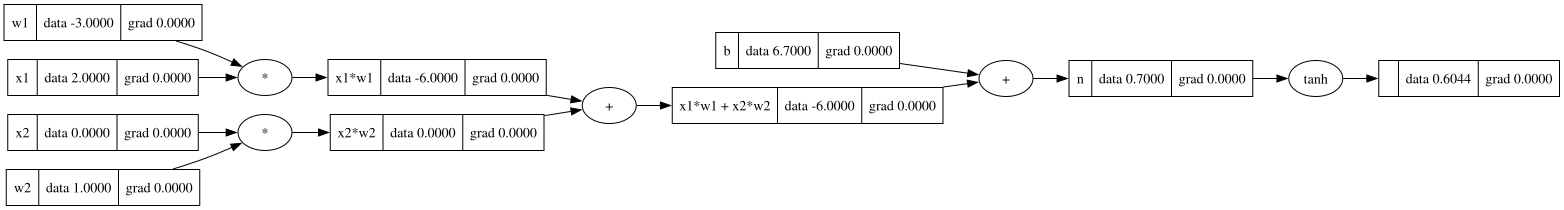

In [104]:
# o = n.tanh(); o.label = 'o'
o = n.tanh()

draw_dot(o)

difference between n and o
- n: 0.7000, 
- o: 0.6044, 
    - tanh squashed .7 -> 0 (closer to 0)
        - input is already pretty low, so doesn't squash much ...

In [105]:
# trying one where it squashes more ...

2.0
0.9640275800758169


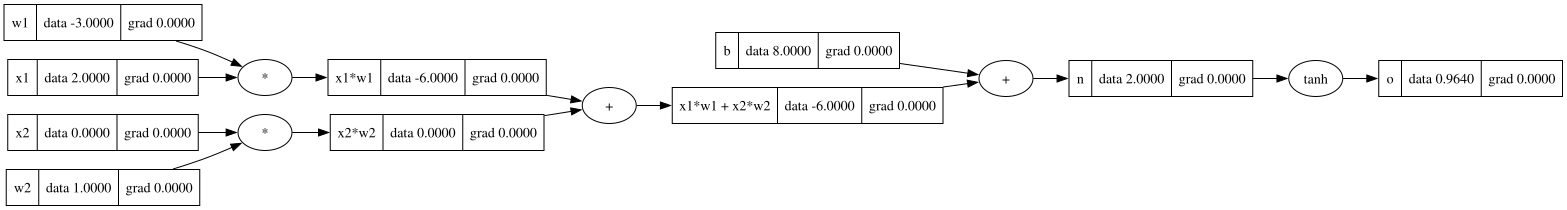

In [106]:
b = Value(8.0, label='b')

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

print(n.data)
print(o.data)

draw_dot(o)




now:
- n: 2.000
- o: 0.9640
    - squashed enough that we are "hitting the tail" of this tanh

In [107]:
# "i am going to do something slightlly strange" (we are about to start backpropogation, and i want our numbers to come out nicely)

0.8813735870195432
0.7071067811865476


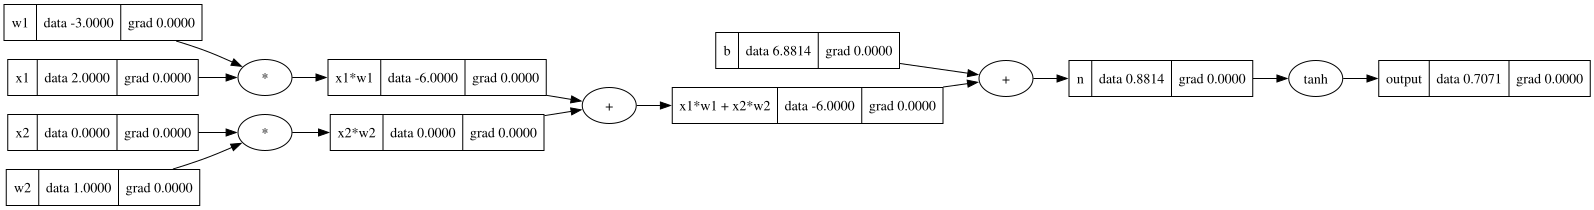

In [108]:
# makes the bias some super exact number ...
b = Value(6.8813735870195432, label='b')

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'output'

print(n.data)
print(o.data)

draw_dot(o)




In [109]:
# now, we will do backpropogation!

what is the derivative O, with respect to all of the inputs here? 
- what we care about most in typical neural network setting: the derivative of the neurons on the weights (w1,w2)
    - why: we will be changing them

note: our network has 1 neuron, but typical ones have many neurons, and they are connected.

said in another way:
- this is 1 neuron (small piece of the puzzle)
- eventually, there is a loss function
    - this measures the accuracy of the neural net
        - we are backpropogating with respect to that accuracy (ie., trying to increase it!)



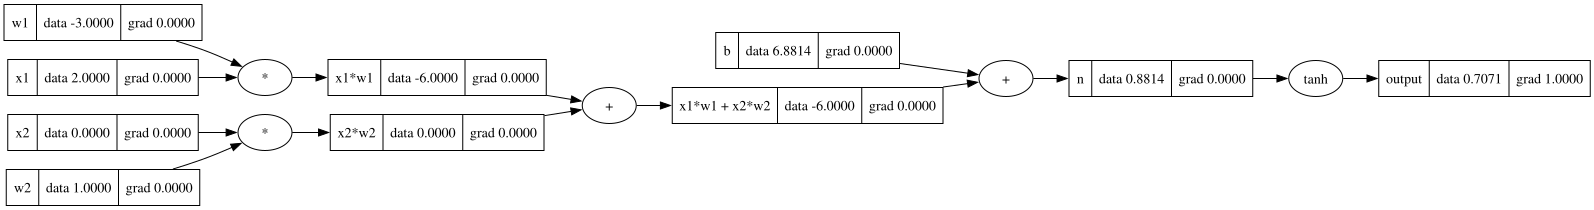

In [110]:
o.grad = 1.0

draw_dot(o)

In [111]:
# next- backpropogate through tanh
# - need to know local derivative of tanh ...

In [112]:
# o = tanh(n)
# what is do/dn?

# 1-do calculus
# or
# 2-1-tanh^2 x

# sooooo
# do/dn = 1-tanh(n)**2
# = 1 - o**2

In [113]:
1

1

In [114]:
o.data

0.7071067811865476

In [115]:
o.data**2

0.5000000000000001

In [116]:
1 - o.data**2

0.4999999999999999

In [117]:
# so, the grad for n (do/dn) is 0.5
# local derivative of do/dn
n.grad = 0.5

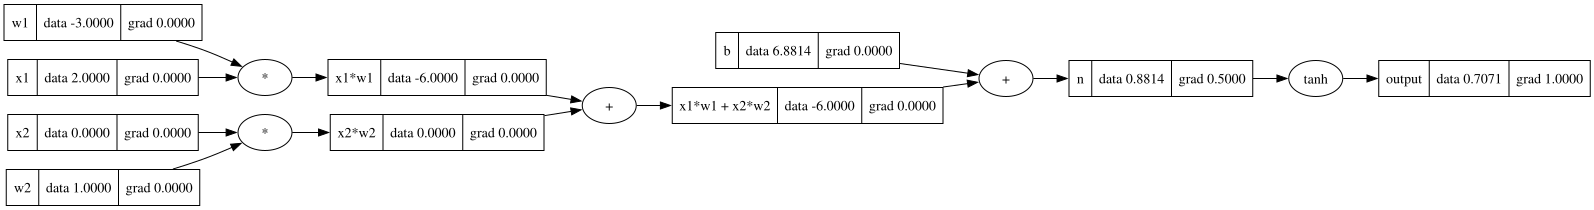

In [118]:
draw_dot(o)

In [119]:
# continue the backpropogation, with:L
# - we have a plus node (so both nodes touching should have the same grad, no?)
# - b: 0.5
# - x1*w1 + x2*w2: 0.5

# - why: grad for n is 0.5, it distributes to both children nodes EQUALLY

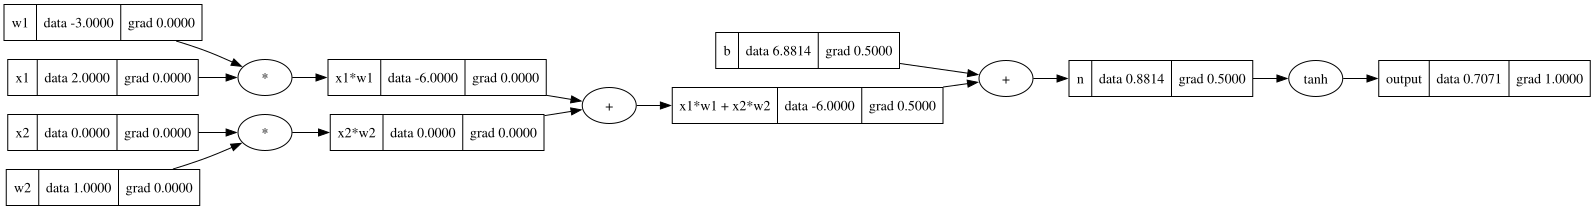

In [120]:
b.grad = 0.5
x1w1x2w2.grad = 0.5

draw_dot(o)



In [121]:
# next 0
# - b: goes to nothing
# - x1*w1 + x2*w2: flows to the following:
#      - x1*w1
#      - x2*w2 (both will get 0.5, because of the plus node)

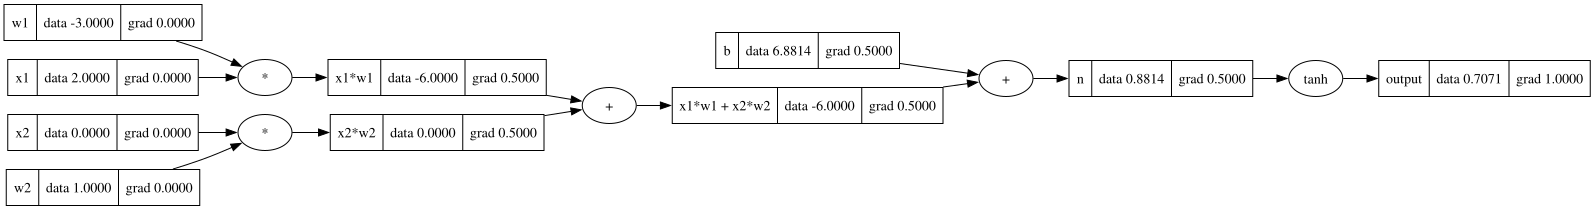

In [122]:
x1w1.grad = 0.5
x2w2.grad = 0.5

draw_dot(o)

reminder: positive value for grad == increase in this leads to increase in the output 

In [123]:
# finally - we are back at the inputs/weights layer

# both have a *, so that means we need to do the chain rule on that
# - x1: 0.5
# - w1: 0.5
# - x2: 0.5
# - w2: 0.5



getting the following:
- x1.grad: 
- w1.grad: 
- x2.grad: 
- w2.grad: ...


Value(data=0.8813735870195432)
Value(data=0.7071067811865476)


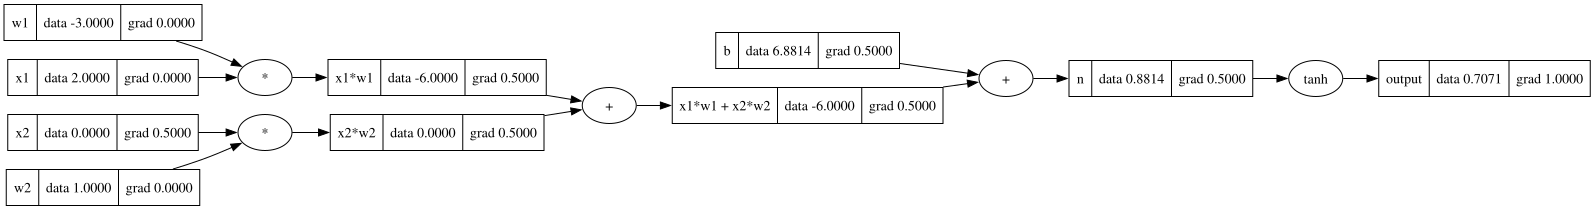

In [124]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

print(n)
print(o)
draw_dot(o)

why the grad for w2 is 0:
- because input x2 is 0, with the way the * works, the gradient is 0
    - w2 could be -10000, 1000000, or 0. all the same because it mulitplies by x2, which is 0

Value(data=0.8813735870195432)
Value(data=0.7071067811865476)


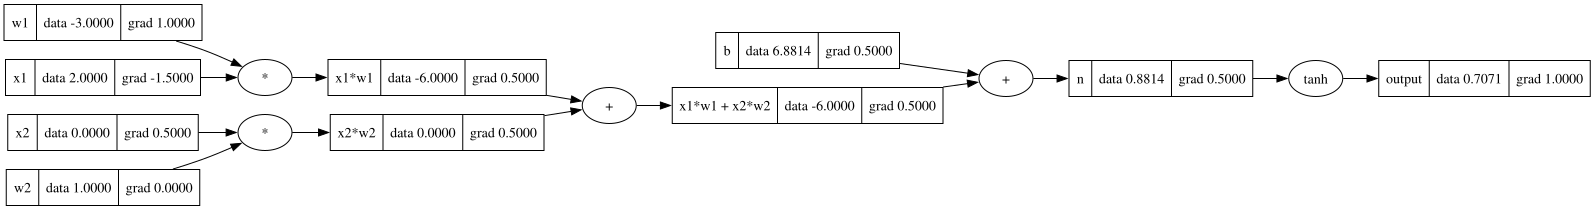

In [125]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

print(n)
print(o)
draw_dot(o)



if we want this neuron's output to increase...
- w2: no gradient (doesn't matter)
- w1: goes up

---

THANK GOD, he says:

"doing this back-propogation manually is obviously ridiculous, so we are going to put an end to this suffering"

(at 1:09 mark ie. 1 hour , 9 min , 8 seconds)

In [126]:
# implement a backward pass a little more automatically ...

In [127]:
# how: start codifying what we see in the examples below


In [128]:
# self._backward
# - function that default does nothing

0.8813735870195432
0.7071067811865476


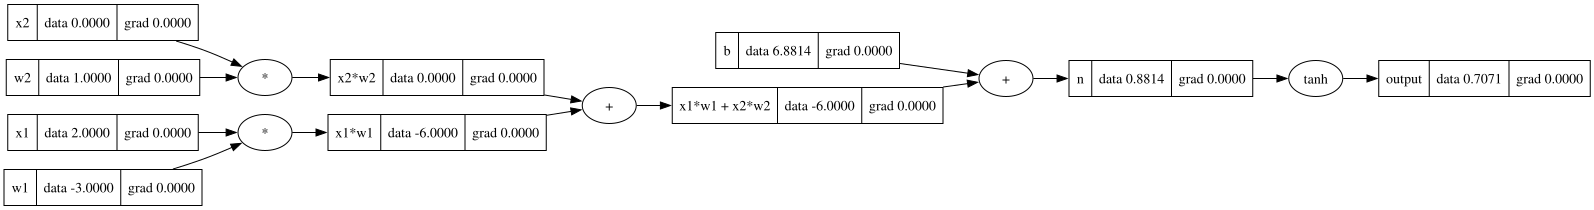

In [129]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        # "internal variables used for autograd graph construction"
        self._backward = lambda: None # this does the chain rule for us - we store how we put outputs gradients -> into inputs gradients
        # base case - leaf node, there is nothing to do (because it has no children)
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        
        # function that propogates the gradient (to the child nodes)
        def _backward():
            # goal
            # self.grad = ???
            # other.grad = ???
            # implementation - take local derivative, times the global derivative (final output), with respect to out
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
        out._backward = _backward#() [we are SAVING these functions, so that ]

        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward#()

        return out

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(
            t,
            (self,),
            'tanh'
        )

        def _backward():
            self.grad = out.grad * (1 - t**2) # t is output of tanh, 
        out._backward = _backward#()

        return out

x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# b = Value(6.7, label='b')
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'output'
print(n.data)
print(o.data)

draw_dot(o)

In [130]:
# make sure all grads are 0... (they are)

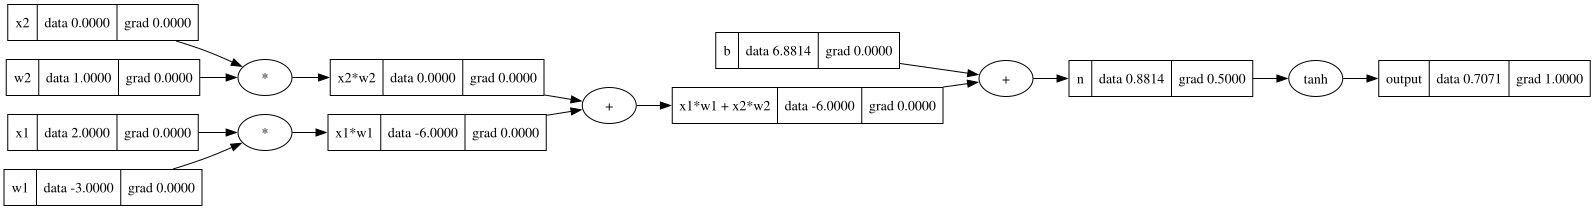

In [131]:
# do "not manually"... (call .backward(), in the right order!)
o.grad = 1.0 # init to 1, because ...
o._backward() # this calls tanh -> grad for n should be 0.5

draw_dot(o)

In [132]:
# now, we can do this for all the nodes!

In [133]:
n._backward() # routes the gradient (of 0.5) to 1-b; 2-x1w1 + x2w2

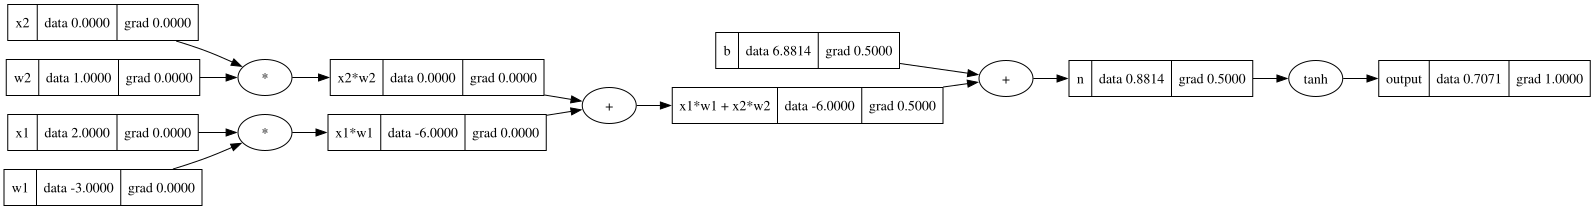

In [134]:
draw_dot(o)

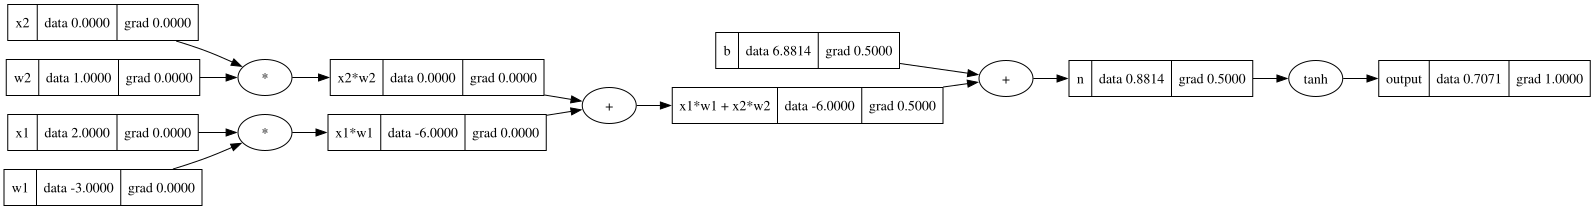

In [135]:
b._backward() # leaf node - by default , backward is None. nothing changes!
draw_dot(o)

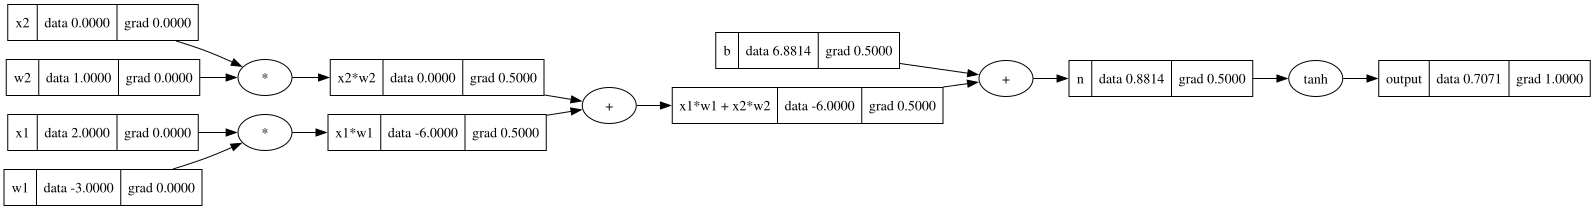

In [136]:
x1w1x2w2._backward() # routes the gradient (of 0.5) to 1-x1w1; 2-x2w2
draw_dot(o)

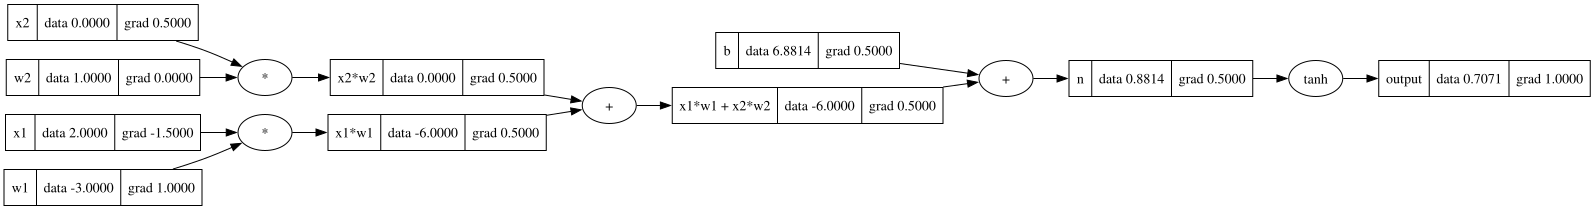

In [137]:
# note: more difficult because instead of '+' operator, these are going back via '*'
x1w1._backward()
x2w2._backward()
draw_dot(o)




we have the same mathematical expression as before!



In [138]:
# one more piece - making it so we don't have to call _backward() manually !

[Value(data=6.881373587019543), Value(data=0.0), Value(data=1.0), Value(data=0.0), Value(data=2.0), Value(data=-3.0), Value(data=-6.0), Value(data=-6.0), Value(data=0.8813735870195432), Value(data=0.7071067811865476)]


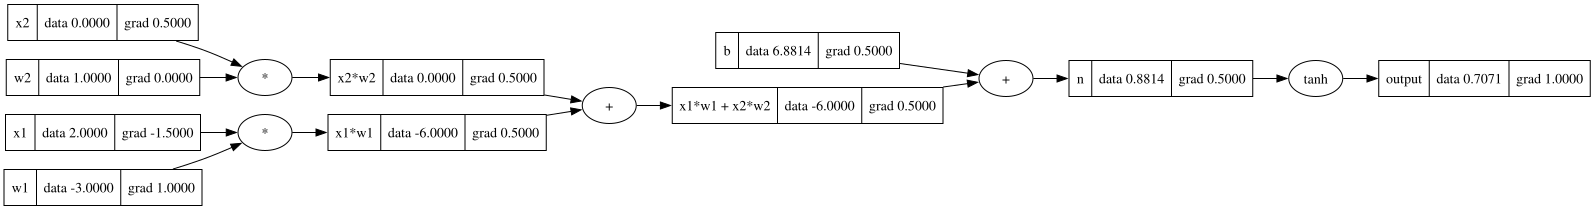

In [139]:
o.grad = 1.0

topo = []
visited = set()

def build_topo(v):
    visited.add(v)
    for child in v._prev:
        build_topo(child)
    topo.append(v)

build_topo(o)
print(topo)

# go thru in reverse
for node in reversed(topo):
    node._backward()

draw_dot(o)

0.8813735870195432
0.7071067811865476


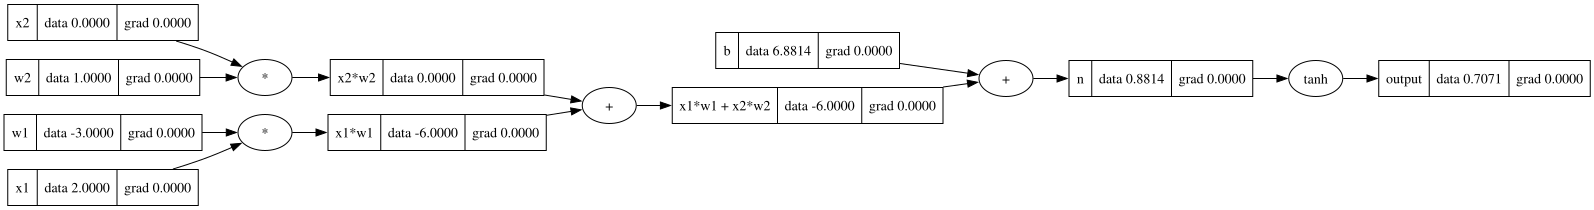

In [140]:
# define backward() in Value()
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward#()
        return out

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(
            t,
            (self,),
            'tanh'
        )

        def _backward():
            self.grad = out.grad * (1 - t**2)
        out._backward = _backward
        return out

    def backward(self):
        # build topological graph, starting at self
        topo = []
        visited = set()

        def build_topo(v):
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)

        # build_topo(o) [this had me conufsed for awhile, forgot to change the var ...]
        build_topo(self)
        
        # set self.grad to 1
        # o.grad = 1.0
        self.grad = 1.0

        # for each node in reverse list, run _backward()
        for node in reversed(topo):
            node._backward()



x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# b = Value(6.7, label='b')
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'output'
print(n.data)
print(o.data)

draw_dot(o)


In [141]:
o.backward()

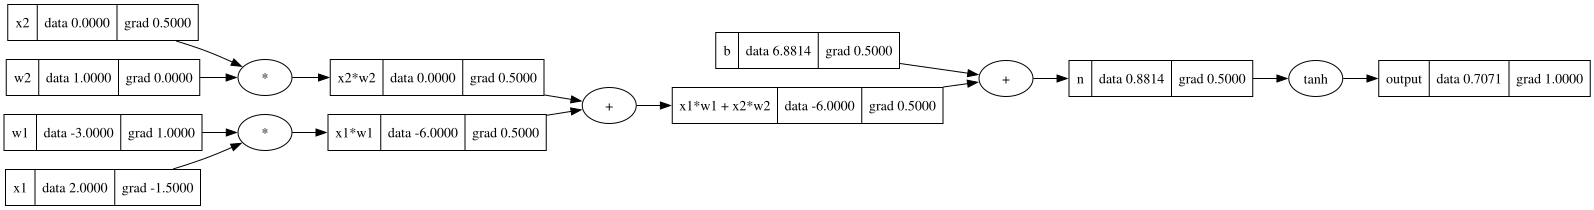

In [142]:
draw_dot(o)

that is backpropogation! (at least with 1 neuron)

---

note: we have 1 bug, so can't be that proud yet ...

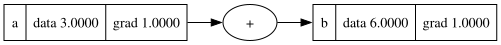

In [143]:
# example to break it
# a = Value(3.0, label='a') # derivative, with respect to b: 0 (the constant 3 goes to 0, there is no b to go to 1)
a = Value(3.0, label='a')
b = a + a; b.label = 'b' # derivative, with respect to a: a+a -> 1+1 -> 2 (db/da = 2, so a.grad is 2)

b.backward()
draw_dot(b)


problem: we are over-riding the gradient ... instead of addding it

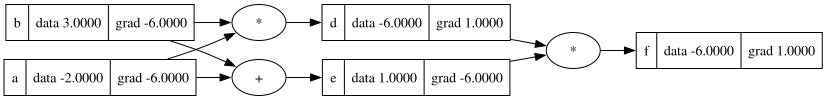

In [144]:
# another way to see this
a = Value(-2.0, label='a')
b = Value (3.0, label='b')

d = a*b; d.label = 'd'
e = a+b; e.label = 'e'
f = d*e; f.label = 'f'

f.backward()
draw_dot(f)



issue: if you use a variable more than 1x, there is an issue
- what happens in backward pass:
    - we backpropogate to variables 2+ times, but we are just overwriting
        - what we should be doing: accumulating
        - how to fix in code: instead of setting, we accumulate ie. `+=`

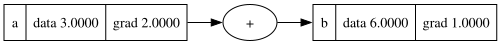

In [145]:
# define backward() in Value()
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad #+=
            other.grad += 1.0 * out.grad #+=
        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad #+=
            other.grad += self.data * out.grad #+=
        out._backward = _backward#()
        return out

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(
            t,
            (self,),
            'tanh'
        )

        def _backward():
            self.grad += out.grad * (1 - t**2) #+=
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)

        build_topo(self)
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()



a = Value(3.0, label='a')
b = a + a; b.label = 'b'

b.backward() # makes a.grad go from 1 -> 2 (2 is correct)
draw_dot(b)

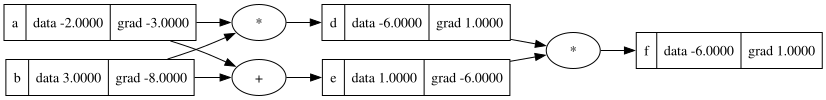

In [146]:
a = Value(-2.0, label='a')
b = Value (3.0, label='b')

d = a*b; d.label = 'd'
e = a+b; e.label = 'e'
f = d*e; f.label = 'f'

f.backward()
draw_dot(f)


he starts doing code cleanup at 1:26:53 ...

---

In [147]:
# back to the non-linerity where we implemented the tanh ...

before: "we could have broken down tanh into its explicit atoms" (in terms of other expressions)
- tanh is derivative
- we can also make it an expressive function of x
    - this forces us to implement divions, subtraction, some other stuff 

WE WILL GET THE SAME RESULT, JUST NEED TO IMPLEMENT MORE CODE


0.8813735870195432
0.7071067811865476


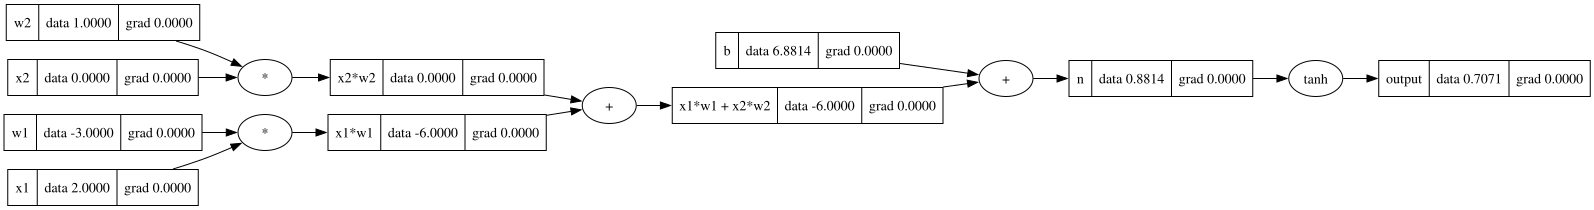

In [148]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'output'
print(n.data)
print(o.data)

draw_dot(o)

In [149]:
o.backward()

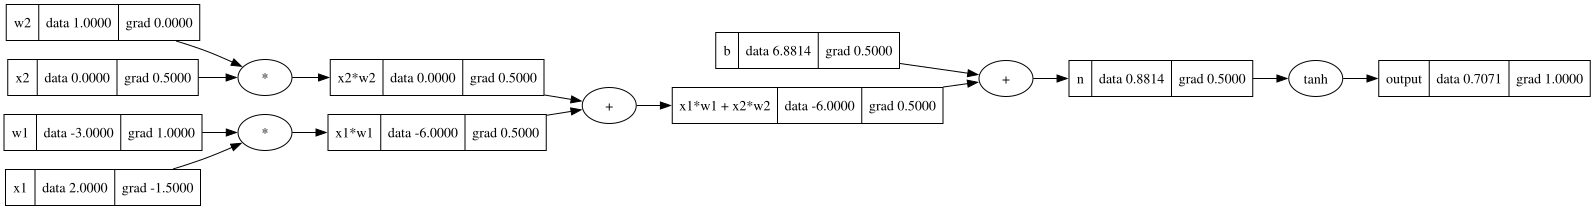

In [150]:
draw_dot(o)

# Add addition to value objects

In [151]:
a = Value(2.0)
# a + 1 #(gets error: AttributeError: 'int' object has no attribute 'data')

In [152]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # add here
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) # add here
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward#()
        return out

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(
            t,
            (self,),
            'tanh'
        )

        def _backward():
            self.grad += out.grad * (1 - t**2)
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)

        build_topo(self)
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

In [153]:
a = Value(2.0)
a+1

Value(data=3.0)

In [154]:
a*2

Value(data=4.0)

In [155]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward#()
        return out

    def __rmul__(self, other):
        return self * other

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(
            t,
            (self,),
            'tanh'
        )

        def _backward():
            self.grad += out.grad * (1 - t**2)
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)

        build_topo(self)
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

In [156]:
a = Value(2.0)
a*2

Value(data=4.0)

In [157]:
2*a

Value(data=4.0)

In [158]:
# 2.__mul__(a)
a.__mul__(2)

Value(data=4.0)

elements we still need:
- exponentiation
- division

In [159]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    # ADDING TO FIX ERROR: TypeError: unsupported operand type(s) for +: 'int' and 'Value'
    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward#()
        return out

    def __rmul__(self, other):
        return self * other

    # division
    # "implementing something more powerful, because division is just a special case of something a bit more powerful"
    # x**k, for some constant k
    # (-1 is division)
    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self * other**-1

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now" # if not int/float, math won't work (that's a diff derivative)
        out = Value(self.data**other, (self,), f'**{other}') # our base case: other=-1

        def _backward():
            # self.grad += other * (self.data ** (other - 1)) # local derivative only, need to multiply by global derivative (out.grad)
            self.grad += other * (self.data ** (other - 1)) * out.grad # this uses the power rule: d/dx x^n * nx^(n-1)
        out._backward = _backward
        return out

    # exponentiation
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.grad * out.data # how to get this? use chain rule 
        out._backward = _backward
        return out

    # also added subtraction
    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(
            t,
            (self,),
            'tanh'
        )

        def _backward():
            self.grad += out.grad * (1 - t**2)
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited: # had forget this line ... lol (was causing gradients to be crazy in the exp() example)
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

In [160]:
a = Value(2.0)
print(a.exp())
# print(a.exp().exp())
# print(a.exp().exp().exp())
# print(a.exp().exp().exp().exp())
# print(a.exp().exp().exp().exp().exp())



Value(data=7.38905609893065)


In [161]:
a = Value(2.0)
b = Value(4.0)
a / b

Value(data=0.5)

In [162]:
a-b

Value(data=-2.0)

In [163]:
...

Ellipsis

In [164]:
# back to the neuron example from before:

0.8813735870195432
0.7071067811865476


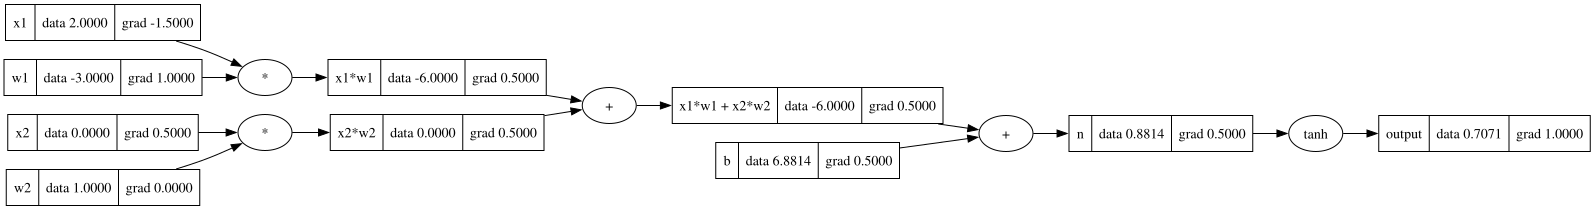

In [165]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'output'
print(n.data)
print(o.data)

# draw_dot(o)
o.backward()
draw_dot(o)
# o.backward()

0.8813735870195432
0.7071067811865477


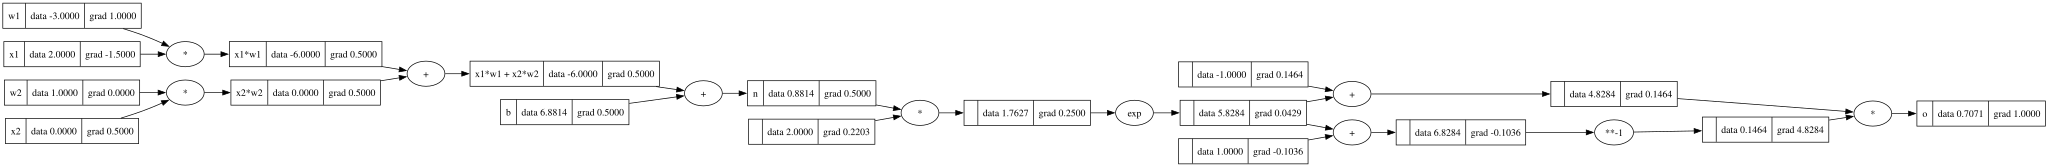

In [166]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
print(n.data)

# ================== changing to the _ ==================

# o = n.tanh(); o.label = 'output'
e = (2*n).exp()
o = (e-1)/(e+1)
print(o.data)

o.label = 'o'

# ======================================================

# draw_dot(o)
o.backward()
draw_dot(o)
# o.backward()

TANH has been broken up into a much longer operations, so we should expect to see a much longer mathematical expression

BUT: the result should be the same! (if so, both forward+backward passes are correct)

why this exercise was good:
- more practice, more operations
- level at which you implmeent your operations are up to you
    - "all that matters is some sort of inputs, and some output. if you can do forward/backward pass, it doesn't matter"

In [167]:
...

Ellipsis

In [168]:
# next - do the same thing, but using a modern deep learning neural network library

time: 1:39:37

---

pytorch: something you would use in production
- "i roughly made autograd for pytorch"
    - microgad: scalar value engine 
        - only scalar values ie. 2.0
    - pytorch: uses tensors 
        - n-dimensional arrays of scalers
            - makes things more complicated ie. making torch.Tensor([2.0]).double()

In [169]:
import torch

In [170]:
# x1 = torch.Tensor([2.0]).double();  x1.requires_grad = True
# x2 = torch.Tensor([0.0]).double();  x2.requires_grad = True
# w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
# w2 = torch.Tensor([1.0]).double();  w2.requires_grad = True
# b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

# n = x1*w1 + x2*w2 + b
# o = torch.tanh(n)

# print(o.data.item())
# o.backward()

# print('---')
# print('x2', x2.grad.item())
# print('w2', w2.grad.item())
# print('x1', x1.grad.item())
# print('w1', w1.grad.item())

In [171]:
t = torch.Tensor(
    [
        [1,2,3],
        [4,5,6]
    ]
)
print(t)
t.shape

tensor([[1., 2., 3.],
        [4., 5., 6.]])


torch.Size([2, 3])

2 by 3 of scalars, in a single compact representation
(usually what you work with in the libraries)

In [172]:
# what we are working with
torch.Tensor([2.0])

tensor([2.])

In [173]:
# put in double precision - Python, by default, uses double precision for floating point numbers 
# (want them to be identical, ie. float64)
torch.Tensor([2.0]).double()

tensor([2.], dtype=torch.float64)

In [174]:
torch.Tensor([2.0]).double().dtype

torch.float64

In [175]:
# because they are leaf nodes, python assumes they do not have gradients... we have to tell Python that they DO need gradients
# (it is trying to be efficient for common cases)
x1 = torch.Tensor([2.0]).double();  x1.requires_grad = True
x2 = torch.Tensor([0.0]).double();  x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double();  w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

In [176]:
# define rest of values, so we can do arithmetic
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

# just like micrograd;
# - .data
# - .grad
print(o.data.item()) # .item(): takes single tensor of 1 element, gives the element (stripping out the tensor)
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [177]:
o # tensor with single element

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [178]:
o.item() # get single number out 

0.7071066904050358

In [179]:
print(x2.grad)
print(x2.item())

tensor([0.5000], dtype=torch.float64)
0.0


"torch can do what we did in micrograd" (as special case, where all tensors are single-element tensors)
- big deal with pytorch: everything is significantly more efficient 
    - we can do lots of operations in parallel

---

now that we have machinery for complex math, we can build out neural nets!
- reminder: they are just a specific class of math expression

eventually: 2 layer multi layer perceptron

In [180]:
# implement a Neuron class, to match what PyTorch does

In [181]:
import random

# BY RE-RUNNING THIS CELL, YOU MAKE IT SO THAT THE VALUES ARE DIFFERENT BC WEIGHTS/BIASES ARE DIFFERENT

class Neuron:
    def __init__(self, nin): # number of inputs, into the neuron
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)] # creates a weight between -1 and 1
        self.b = Value(random.uniform(-1,1)) # controls overall "trigger-happiness"

    def __call__(self, x): # x: 
        # w * x + b (dot product)
        # test
        # print(list(zip(self.w, x)))

        # act = sum(wi*xi for wi, xi in zip(self.w, x)), self.b # (Need to add __radd__ to the Value class, since it ends up being 0 + Value(...))
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) # uses a generator
        out = act.tanh()
        
        return out


x = [2.0, 3.0]
n = Neuron(2)
n(x)

        

Value(data=0.6779271352691976)

In [182]:
# note - you get a different output each time, because you are init'ing different weights/biases

In [183]:
# we can forward a single neuron!

In [184]:
# next - a layer of neurons (set of neurons, evaluated independently)

In [185]:
class Layer:
    def __init__(self, nin, nout): # inputs: # inputs, # outputs
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        # return outs
        return outs[0] if len(outs) == 1 else outs # prevents returning a list of 1 element

x = [2.0, 3.0] # input is 2 neurons
n = Layer(2,3) # outputs 3 neurons
n(x)

[Value(data=0.9431950945140146),
 Value(data=-0.9719278580138719),
 Value(data=0.8947355442501135)]

In [186]:
# draw_dot(n) [can't do]

In [187]:
# ok , now let's finish it up and construct and MLP ie. multi-layer perceptron
# - what this MLP is: the layers feed into each other sequentialy

In [188]:
class MLP:
    def __init__(self, nin, nouts): # inputs: # inputs, # outputs
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers: # calling them sequentially
            x = layer(x)
        return x
        

x = [2.0, 3.0, -4.0] # input is 3 neurons
n = MLP(3, [4,4,1])  # output
n(x)
        

Value(data=0.8432070448020829)

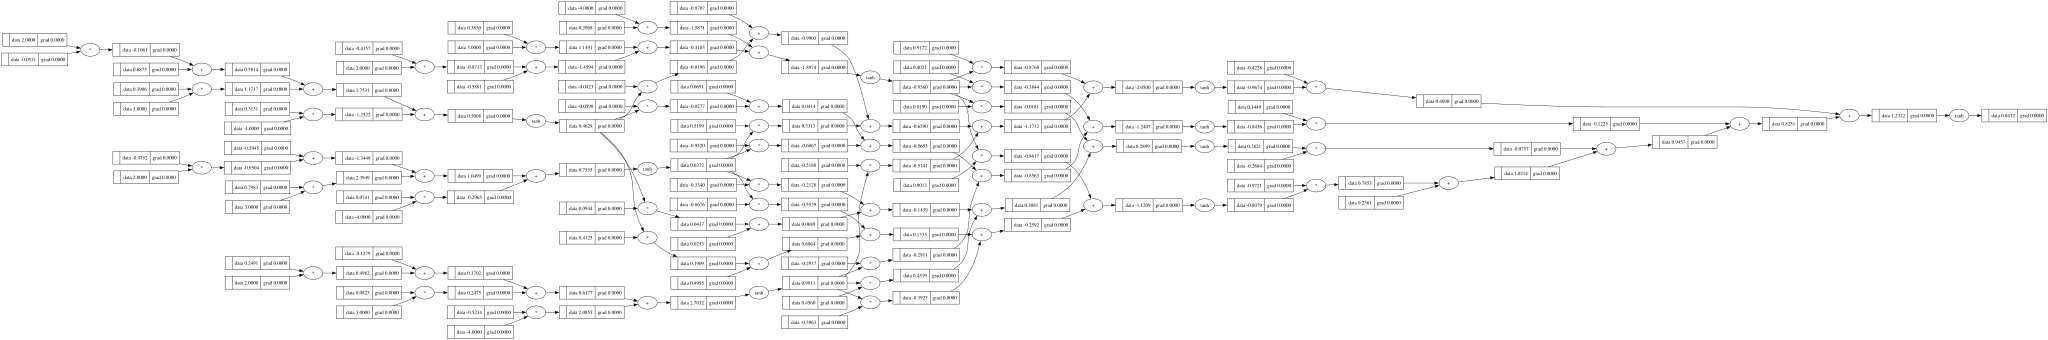

In [189]:
draw_dot(n(x))

"these expressions are getting relatively involved!"
- you could never do all of this on pen and paper ...

In [190]:
# very simple - example dataset
# 4 rows of data
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]


# 4 desired targets 
ys = [1.0, -1.0, -1.0, 1.0]

# pred (outputs of the neural net)
ypred = [n(x) for x in xs]
print(ypred)

# loss
# loss = sum((yout-y)**2 for yout, y in zip(ypred, ys))
# loss


[Value(data=0.7655498156351352), Value(data=0.15835179132217214), Value(data=-0.12290867907183986), Value(data=0.5151672153347918)]


In [191]:
# doing basic analysis into what we want the trgets to do ...
for yout, y in zip(ypred, ys):
    direction = "up" if yout.data < y else "down"
    print(f"{yout.data:.3f}", "target:", y, "move:", direction)

0.766 target: 1.0 move: up
0.158 target: -1.0 move: down
-0.123 target: -1.0 move: down
0.515 target: 1.0 move: up


"how do we tune the weights to better predict the desired targets"
- trick used in deep learning:
    - calculate single number that measures the total performance of the neural net
        - loss: measures how the NN is performing (rn, it is doing bad ...)

In [192]:
# mean squared error loss
# - below: these are individual loss components
for y_groundtruth, y_prediction in zip(ys, ypred):
    # print(f"{y_groundtruth:.3f}", "prediction:", f"{y_prediction.data:.3f}")
    temp_loss = (y_prediction.data - y_groundtruth)**2
    print(f"{temp_loss:.3f}")

0.055
1.342
0.769
0.235


In [193]:
individual_losses = [(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]
# loss = sum(individual_loss)
individual_losses

[Value(data=0.054966888948719074),
 Value(data=1.341778872459285),
 Value(data=0.7692891852475048),
 Value(data=0.23506282908622012)]

In [194]:
# help from chatgpt - dumb this down
for i, (y_true, y_pred) in enumerate(zip(ys, ypred), 1):
    pred = y_pred.data
    error = pred - y_true
    loss = error**2

    # qualitative description
    abs_error = abs(error)
    if abs_error < 0.3:
        quality = "very close to optimal"
    elif abs_error < 0.7:
        quality = "somewhat close"
    elif abs_error < 1.2:
        quality = "far"
    else:
        quality = "very far (bad)"

    direction = "increase" if pred < y_true else "decrease"

    print(f"Datapoint {i}:")
    print(f"  prediction = {pred:.3f}, target = {y_true:.3f}")
    print(f"  error      = {error:.3f}")
    # print(f"  loss       = {loss:.3f} (squared error ie. {error**2:.3f} == {loss:.3f})")
    print(f"  loss       = {loss:.3f} (squared error ie. {error:.3f}^2 == {loss:.3f})")
    print(f"  → need to {direction} output")
    print(f"  → this is {quality}")
    print()

Datapoint 1:
  prediction = 0.766, target = 1.000
  error      = -0.234
  loss       = 0.055 (squared error ie. -0.234^2 == 0.055)
  → need to increase output
  → this is very close to optimal

Datapoint 2:
  prediction = 0.158, target = -1.000
  error      = 1.158
  loss       = 1.342 (squared error ie. 1.158^2 == 1.342)
  → need to decrease output
  → this is far

Datapoint 3:
  prediction = -0.123, target = -1.000
  error      = 0.877
  loss       = 0.769 (squared error ie. 0.877^2 == 0.769)
  → need to decrease output
  → this is far

Datapoint 4:
  prediction = 0.515, target = 1.000
  error      = -0.485
  loss       = 0.235 (squared error ie. -0.485^2 == 0.235)
  → need to increase output
  → this is somewhat close



In [195]:
...

Ellipsis

In [196]:
print(ys)
print(ypred)
print(x.data for x in ypred)

loss=sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

[1.0, -1.0, -1.0, 1.0]
[Value(data=0.7655498156351352), Value(data=0.15835179132217214), Value(data=-0.12290867907183986), Value(data=0.5151672153347918)]
<generator object <genexpr> at 0x1131c7f40>


Value(data=2.401097775741729)

In [197]:
n.layers[0].neurons[0].w[0].grad # should be 0 (we haven't computed the gradients yet via .backward())

0.0

In [198]:
# 
loss.backward()

In [199]:
# MLP has layers
# layers have neurons
# neurons have weights and biases
n.layers[0].neurons[0].w[0]

Value(data=-0.05307435285988116)

In [200]:
n.layers[0].neurons[0].w[0].grad

-1.9782894811540752

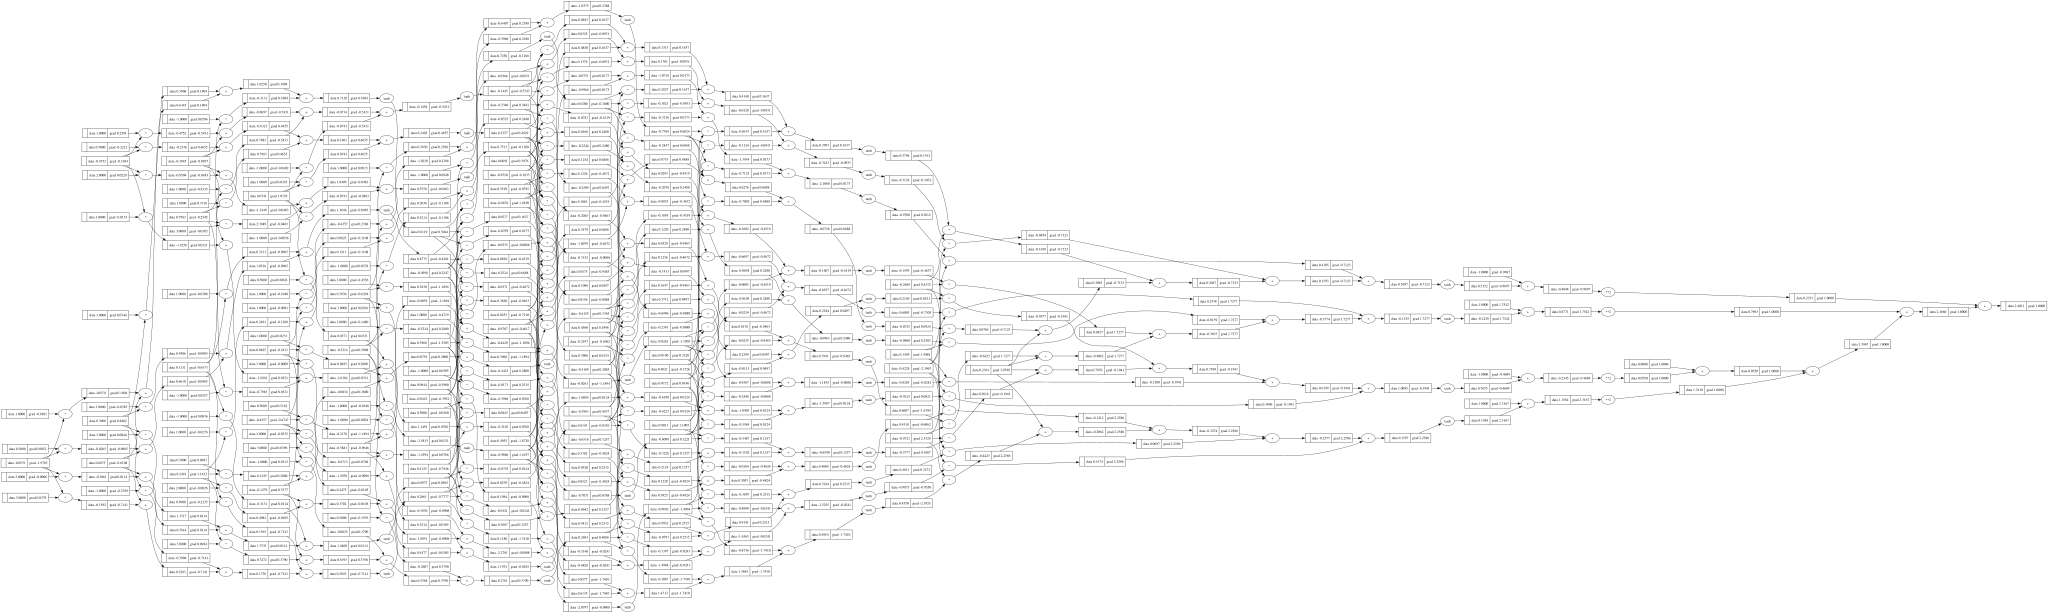

In [201]:
draw_dot(loss) # massive graph - we forwarded all 4 examples, so 4 forwrd passes of the neural net. then loss on top (which backpropogates thru each intermedaite value, to the inputs)

gradients on input data: not that useful to use
- why: it's a given (ie. fixed input to the problem)
- what we DO want to change:
    - w/weights
    - b/biases

In [202]:
# convenience code: gather all params of nn
# - we can nudge all of them a "tiny bit" based on the gradient information

class Neuron:
    def __init__(self, nin): # number of inputs, into the neuron
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self): # get all params in 1 array
        return self.w + [self.b] # list, concat with self.b
        # pytorch: also has .parameters() method on every single module !
        
class Layer:
    def __init__(self, nin, nout): # inputs: # inputs, # outputs
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()] # list comprehension, to make the array
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extend()
        # return params

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        # for layer in self.layers:
        #     x = layer(x)
        # return x


Value(data=-0.39411843529363977)


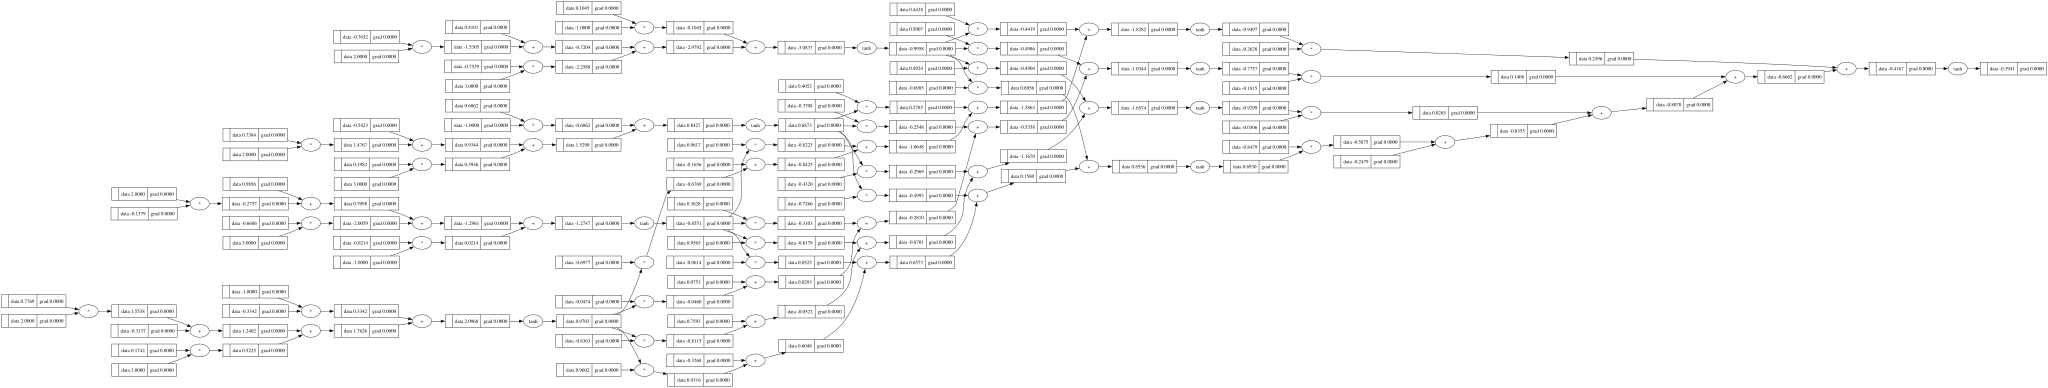

In [203]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
print(n(x))

draw_dot(n(x))

In [204]:
print(len(n.parameters())) # n=41 params

n.parameters() # this is all the parameters in the neural net
# (all of the weights and biases)



41


[Value(data=0.7769215716631797),
 Value(data=0.17416003957014747),
 Value(data=-0.3341545905370351),
 Value(data=-0.31368261309087564),
 Value(data=-0.13786444574587753),
 Value(data=-0.6686462448446151),
 Value(data=-0.021430777926712663),
 Value(data=0.985558336943114),
 Value(data=0.7383633740745175),
 Value(data=0.19820133684378805),
 Value(data=0.6862366864776079),
 Value(data=-0.542345431595163),
 Value(data=-0.7652377369021544),
 Value(data=-0.7529394539051835),
 Value(data=0.10453944782477853),
 Value(data=0.8101120181589541),
 Value(data=0.9601827058546224),
 Value(data=-0.06141805835382552),
 Value(data=-0.7265638991037786),
 Value(data=-0.6985456043603346),
 Value(data=-0.3268148448867205),
 Value(data=-0.8363425571923551),
 Value(data=0.9565467900439133),
 Value(data=-0.4320409697196186),
 Value(data=0.492425772550835),
 Value(data=0.7593191788152696),
 Value(data=-0.047416338936547175),
 Value(data=0.36284901065561703),
 Value(data=-0.3707908329963008),
 Value(data=0.50072

In [205]:
# we can change them... by recalculating the loss (will be diff than before)

In [206]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]
ypred = [n(x) for x in xs]
print(ypred)



[Value(data=-0.39411843529363977), Value(data=-0.4023218011905421), Value(data=0.21574407041833105), Value(data=-0.6075215470249736)]


In [207]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss_before_update = loss
print(f"loss before update: {loss_before_update.data:.5f}")


loss before update: 6.36294


In [208]:
# backward pass: compute gradients
# we MUST run this every iteration because:
# - gradients depend on current parameter values
# - after we update parameters, old gradients are no longer valid
# - if we don’t recompute, we keep using stale gradients → wrong updates

loss.backward() # if we don't run this, the gradients will not be computed (how many times we need to run this: )

In [209]:
# print(n.layers[0].neurons[0].w[0].grad:.3f)
# print(n.layers[0].neurons[0].w[0].data:.3f)

# print(f"gradient: {n.layers[0].neurons[0].w[0].grad:.5f}")
# print(f"data: {n.layers[0].neurons[0].w[0].data:.5f}")

gradient_before_update = n.layers[0].neurons[0].w[0].grad
data_before_update = n.layers[0].neurons[0].w[0].data

print(f"gradient before update: {gradient_before_update:.5f}")
print(f"data before update: {data_before_update:.5f}")



gradient before update: -0.29511
data before update: 0.77692


In [210]:
# n.parameters()

# what we want to do: for eery parameteer in parametrs (n=41), we want to change p.data (slightly, according to the gradient information)
# - "a tiny update in the gradient descent scheme"
# - gradient: vector pointing in the direction of increased loss ie. better performance

step_size = 0.01

for p in n.parameters():
    # p.data += step_size * p.grad # this would increase the gradient by a tiny amount .. 
    p.data += -step_size * p.grad # this would DECREASE the  gradient by a tiny amount .. (we want to minimize the loss)


In [211]:
ypred = [n(x) for x in xs]
print(ypred)

[Value(data=-0.264057977120382), Value(data=-0.40675892962406185), Value(data=0.1525581491900036), Value(data=-0.5489042952775545)]


In [212]:
# because we changed these parameters, the loss should have gone DOWN a bit (ie. better performing neural net)

In [213]:
# after nudging the gradients all a tiny amount, it ...
gradient_after_update = n.layers[0].neurons[0].w[0].grad
data_after_update = n.layers[0].neurons[0].w[0].data

print(f"gradient after update: {gradient_after_update:.5f}")
print(f"data after update: {data_after_update:.5f}")


loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss_after_update = loss
print(f"loss after update: {loss_after_update.data:.5f}")

# difference = loss_after_update.data - loss_before_update.data
# print(f"difference: {difference:.5f}")



gradient after update: -0.29511
data after update: 0.77987
loss after update: 5.67727


In [214]:
# # compare gradient before/after
# gradient_diff = gradient_after_update - gradient_before_update
# print(f"gradient difference: {gradient_diff:.5f} ({gradient_after_update.data:.5f} - {gradient_before_update.data:.5f})")
# if gradient_diff < 0:
#     print("gradient went down! (neural net is performing better)")
# else:
#     print("gradient went up! (neural net is performing worse)")

# # compare data before/after
# data_diff = data_after_update - data_before_update
# print(f"data difference: {data_diff:.5f} ({data_after_update.data:.5f} - {data_before_update.data:.5f})")
# if data_diff < 0:
#     print("data went down! (neural net is performing better)")
# else:
#     print("data went up! (neural net is performing worse)")

# # compare loss before/after
# loss_diff = loss_after_update.data - loss_before_update.data
# print(f"loss difference: {loss_diff:.5f} ({loss_after_update.data:.5f} - {loss_before_update.data:.5f})")
# if loss_diff < 0:
#     print("loss went down! (neural net is performing better)")
# else:
#     print("loss went up! (neural net is performing worse)")

# --- BEFORE UPDATE ---
print("=== BEFORE UPDATE ===")
print(f"param value:   {data_before_update:.6f}")
print(f"gradient:      {gradient_before_update:.6f}")
print(f"loss:          {loss_before_update.data:.6f}")

# --- AFTER UPDATE ---
print("\n=== AFTER UPDATE ===")
print(f"param value:   {data_after_update:.6f}")
print(f"gradient:      {gradient_after_update:.6f}")
print(f"loss:          {loss_after_update.data:.6f}")

# --- CHANGES ---
print("\n=== CHANGES ===")

param_diff = data_after_update - data_before_update
grad_diff = gradient_after_update - gradient_before_update
loss_diff = loss_after_update.data - loss_before_update.data

print(f"Δparam:        {param_diff:.6f}")
print(f"Δgradient:     {grad_diff:.6f}")
print(f"Δloss:         {loss_diff:.6f}")

# --- INTERPRETATION ---
print("\n=== INTERPRETATION ===")

# Only loss determines "better/worse"
if loss_diff < 0:
    print("✔ Loss decreased → model improved (for this step)")
else:
    print("✘ Loss increased → step may be too large or unstable")

# Gradient is just diagnostic
print("• Gradient change is diagnostic (not a performance signal)")

# Parameter movement sanity check
if param_diff != 0:
    print("• Parameters updated as expected")
else:
    print("• Warning: parameters did not change")

=== BEFORE UPDATE ===
param value:   0.776922
gradient:      -0.295109
loss:          6.362945

=== AFTER UPDATE ===
param value:   0.779873
gradient:      -0.295109
loss:          5.677272

=== CHANGES ===
Δparam:        0.002951
Δgradient:     0.000000
Δloss:         -0.685672

=== INTERPRETATION ===
✔ Loss decreased → model improved (for this step)
• Gradient change is diagnostic (not a performance signal)
• Parameters updated as expected


LOW LOG-LOSS: PREDICTIONS ARE MATCHING THE TARGET

In [215]:
# WHAT WE DO NOW: iterate this process!
# - update the parameters
# - recalculate the loss
# - repeat until the loss is minimized

# this is the "learning" process
# ("forward pass", "backward pass", "update parameters", )

In [216]:
...

Ellipsis

In [217]:
iters = 100#00
step_size = 0.01

total_iters_done= 0

for i in range(iters):

    # forward pass: compute predictions and loss (current model state)
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass: compute gradients for ALL parameters
    # must run every iteration because gradients depend on current parameter values
    loss.backward()

    # optional: inspect before update (just for debugging/intuition)
    gradient_before_update = n.layers[0].neurons[0].w[0].grad
    data_before_update = n.layers[0].neurons[0].w[0].data

    # update parameters using the gradients (gradient descent step)
    for p in n.parameters():
        p.data += -step_size * p.grad

    # zero gradients so they don’t accumulate across iterations
    # if we DON'T do this:
    # - gradients from previous steps keep adding up
    # - updates become larger and incorrect
    # - training can become unstable or diverge
    for p in n.parameters():
        p.grad = 0.0

    # print progress
    print(f"loss after {i+1} iterations: {loss.data:.5f}")

    # show predictions moving toward targets [1, -1, -1, 1]
    print(f"predictions: {[round(x.data, 5) for x in ypred]}")
    print()

    total_iters_done += 1
    if total_iters_done % 100 == 0:
        print(f"total iters done: {total_iters_done}")


loss after 1 iterations: 5.67727
predictions: [-0.26406, -0.40676, 0.15256, -0.5489]

loss after 2 iterations: 4.36232
predictions: [0.01862, -0.40419, 0.03039, -0.40802]

loss after 3 iterations: 3.80083
predictions: [0.14861, -0.39949, -0.02361, -0.32742]

loss after 4 iterations: 3.30480
predictions: [0.2619, -0.39869, -0.07815, -0.24444]

loss after 5 iterations: 2.87002
predictions: [0.35731, -0.40248, -0.13324, -0.16132]

loss after 6 iterations: 2.49000
predictions: [0.43644, -0.41066, -0.18822, -0.07987]

loss after 7 iterations: 2.15926
predictions: [0.50177, -0.42265, -0.24214, -0.00167]

loss after 8 iterations: 1.87338
predictions: [0.55572, -0.4377, -0.29402, 0.07188]

loss after 9 iterations: 1.62825
predictions: [0.6004, -0.45503, -0.34303, 0.13979]

loss after 10 iterations: 1.41957
predictions: [0.63757, -0.47386, -0.3886, 0.20151]

loss after 11 iterations: 1.24284
predictions: [0.66868, -0.49351, -0.4304, 0.25697]

loss after 12 iterations: 1.09354
predictions: [0.69

In [218]:
# trying with way too big of a step size
iters = 500
step_size = 1.0  # too large can overstep the minimum and destabilize training
total_iters_done = 0

xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

for i in range(iters):
    # forward pass before update
    ypred = [n(x) for x in xs]
    loss_before = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    loss_before.backward()

    # update parameters
    for p in n.parameters():
        p.data += -step_size * p.grad

    # clear gradients
    for p in n.parameters():
        p.grad = 0.0

    # forward pass after update, to check whether loss improved
    ypred_after = [n(x) for x in xs]
    loss_after = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred_after))

    print(f"iteration {i+1}")
    print(f"loss before update: {loss_before.data:.5f}")
    print(f"loss after update:  {loss_after.data:.5f}")
    print(f"predictions after: {[round(x.data, 5) for x in ypred_after]}")

    if loss_after.data > loss_before.data:
        print("STOPPING: loss got worse after the update")
        print("This means we probably overstepped the minimum.")
        break

    print()

    total_iters_done += 1

print(f"total iters done: {total_iters_done}")

iteration 1
loss before update: 0.04033
loss after update:  0.01035
predictions after: [0.96838, -0.95176, -0.95073, 0.93222]

iteration 2
loss before update: 0.01035
loss after update:  0.00701
predictions after: [0.97374, -0.96028, -0.95913, 0.94455]

iteration 3
loss before update: 0.00701
loss after update:  0.00535
predictions after: [0.97691, -0.96537, -0.9642, 0.95166]

iteration 4
loss before update: 0.00535
loss after update:  0.00434
predictions after: [0.9791, -0.96888, -0.96772, 0.95652]

iteration 5
loss before update: 0.00434
loss after update:  0.00365
predictions after: [0.98074, -0.97149, -0.97036, 0.96014]

iteration 6
loss before update: 0.00365
loss after update:  0.00315
predictions after: [0.98203, -0.97354, -0.97244, 0.96296]

iteration 7
loss before update: 0.00315
loss after update:  0.00278
predictions after: [0.98308, -0.9752, -0.97413, 0.96526]

iteration 8
loss before update: 0.00278
loss after update:  0.00248
predictions after: [0.98396, -0.97658, -0.9755

In [219]:
# these are the weights / parameters that make our neural net predict well
n.parameters()

[Value(data=0.7390951896893563),
 Value(data=0.18300700436822723),
 Value(data=-0.49615958879703137),
 Value(data=-0.3425525785475054),
 Value(data=-0.18508362501600856),
 Value(data=-0.9090516468217602),
 Value(data=0.77894360751825),
 Value(data=0.9250111753695291),
 Value(data=0.8716978694031278),
 Value(data=0.3583243416043523),
 Value(data=0.49105753974821525),
 Value(data=-0.439681075433266),
 Value(data=-0.44027568590825883),
 Value(data=-0.8753748078419955),
 Value(data=0.412775799342412),
 Value(data=0.9421572197375698),
 Value(data=0.8623200630472769),
 Value(data=0.23720113256629824),
 Value(data=-0.5744515897321045),
 Value(data=-0.5766358376860387),
 Value(data=-0.29722928102420326),
 Value(data=-0.8806312866054351),
 Value(data=1.2108092226502611),
 Value(data=-0.2783333954271433),
 Value(data=0.6147631447184521),
 Value(data=0.7616390202688946),
 Value(data=-0.13533581098675987),
 Value(data=0.6776053475231707),
 Value(data=-0.16910819990610843),
 Value(data=0.6482704122

we have successfully trained a neural net!

reminder:
- forward pass
- backward pass
- update
    - neural network improves its predictions!

subtle "art" of tuning / learning rate (for vanilla gradient descent)
- learning rate too low: takes too long to find the optimal soln
- learning rate too high: might explode the loss

In [220]:
# neural net
# x = [2.0, 3.0, -1.0] # meaning: 3 random inputs
x = [2.0, 3.0, -1.0] # one input example with 3 features
n = MLP(3, [4,4,1]) # meaning: 3 inputs, 4 neurons in the first layer, 4 neurons in the second layer, 1 neuron in the output layer

# data
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]


# Andrej's loop version (above is me / chatgpt)
i=20
step_size = 0.05

for k in range(i):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # zero gradients (forgot to add this, at first)
    # explanation on why it is important:
    # - all weights have .data and .grad
    # - .grad starts at 0.0
    # - we update the gradients
    # - at the 2nd forward pass, the gradients are not 0.0, they are the gradients from the previous forward pass
    # - if we don't zero them, they will keep accumulating
    
    for p in n.parameters(): # how to fix: iterate over all parameters and set the gradient to 0.0
        p.grad = 0.0

    # backward pass
    loss.backward()

    # update parameters
    for p in n.parameters():
        p.data += -step_size * p.grad

    print(f"loss after {k+1} iterations: {loss.data:.5f}")
    # ... repeat until the loss is minimized




loss after 1 iterations: 4.47165
loss after 2 iterations: 3.24185
loss after 3 iterations: 2.89145
loss after 4 iterations: 2.56278
loss after 5 iterations: 2.22910
loss after 6 iterations: 1.87076
loss after 7 iterations: 1.47018
loss after 8 iterations: 1.05811
loss after 9 iterations: 0.71888
loss after 10 iterations: 0.49213
loss after 11 iterations: 0.35257
loss after 12 iterations: 0.26558
loss after 13 iterations: 0.20878
loss after 14 iterations: 0.16979
loss after 15 iterations: 0.14184
loss after 16 iterations: 0.12104
loss after 17 iterations: 0.10508
loss after 18 iterations: 0.09252
loss after 19 iterations: 0.08241
loss after 20 iterations: 0.07414


In [221]:
print(ypred)
print([round(x.data, 5) for x in ypred]) # 4/4

[Value(data=0.9345741379100914), Value(data=-0.9509396049523695), Value(data=-0.8069927320546176), Value(data=0.8262271284197178)]
[0.93457, -0.95094, -0.80699, 0.82623]


we converged to a loss that is very low ....

---
random: shows 5 most common neural net mistakes (tweet)

1) you didn't try to overfit a single batch first.

2) you forgot to toggle train/eval mode for the net.

3) you forgot to .zero_grad() (in pytorch) before .backward(). [I AM PRETTY SURE THIS IS WHAT WE FORGOT TO DO, HENCE CHATGPT HAD IT BUT ANDREJ DID NOT]
- only reason ours worked: this was a very simple/trivial problem
    - it effectively just gave us a masssive step size ...

4) you passed softmaxed outputs to a loss that expects raw logits.

5) you didn't use bias=False for your Linear/Conv2d layer when using BatchNorm, or forgot to include it for the output layer.



"working with neural nets is sometimes tricky"
- you might have bugs in the code, yet it STILL WORKS

---

Let's bring everything together, and summarize what we have learned:

1. neural nets are these mathematical expressions
- MLP (multi layer perceptron): simple math expression
- inputs:
    - data
    - weights (parameters)
    - math expression for forward pass (makes predictions)
    - loss function calculates accuracy of predictions
        - loss is low when network is doing "good"

    - backpropagation to get the gradient
        - computes how each weight affects the loss

    - gradient descent to tune the params
        - uses the gradients to update weights:
            w = w - η ∇L

    - repeat this process many times to minimize loss

"you can make neural nets with billions of params" (ours had n=41)

emerging properties of advanced neural nets:
- GPT: trained on massive amounts of text
    - neural net takes a couple of words, predicts the next word
        - can have hundreds of millions to billions of parameters

---

beginning of video: i said "you will understand all of the code in micrograd"
- engine.py:
    - Value()
        - added relu(), which is a non-linear activation function
            - returns max(0, x)
            - lets the network learn more complex patterns (otherwise it's just linear)
            - note on activation functions: "not big diff inn relu/tanh/sigmoid, all can be used in MLP"
                - Andrej uses tanh in this video because "it is a bit smoother, and more complicated than ReLU"

- nn.py
    - Module()
        - parents class of all the modules
        - used to match pytorch
    - Neuron()
    - Layer()
    - MLP()

In [222]:
# clone the repo, run the test_engine.py file to see that it works
# - this compares micrograd and pytorch

In [223]:
!pwd

/Users/thomasmyles/dev/neural-networks


In [224]:
# clone the repo
!git clone https://github.com/karpathy/micrograd.git

fatal: destination path 'micrograd' already exists and is not an empty directory.


In [225]:
# !PYTHONPATH=. python micrograd/test/test_engine.py

neural-networks/
    micrograd/        ← repo root (THIS is what should be on PYTHONPATH)
        micrograd/    ← actual python package
            engine.py
        test/
            test_engine.py

...

What PYTHONPATH=. means
- PYTHONPATH tells Python where to look for modules
- . means “current directory”

So you told Python:

“Also treat the current folder as a place to import packages from”

In [226]:
!PYTHONPATH=./micrograd python micrograd/test/test_engine.py

In [227]:
%cd micrograd
!python -m pytest test/test_engine.py

/Users/thomasmyles/dev/neural-networks/micrograd


============================= test session starts ==============================
platform darwin -- Python 3.13.3, pytest-9.0.2, pluggy-1.6.0
rootdir: /Users/thomasmyles/dev/neural-networks/micrograd
plugins: anyio-4.12.0, timeout-2.4.0, langsmith-0.4.56, typeguard-4.4.4
collected 2 items                                                              

test/test_engine.py ..                                                   [100%]

============================== 2 passed in 0.88s ===============================


---

...

finally: demo, that is more advanced than what we did in this lecture...
- us: tiny dataset of 4 examples
    - we had so few 
        - did not need to batch ... not enough data!
        
- this: map with lots of blue/red points
    - buildling binary classifier
    - "more complicated MLP"
    - more complicated loss
        - batch: random subset
        - supports batches for the `forward -> backward -> update`
        - used a max-margin loss function
            - could have used binary cross entropy (doesn't make much of a difference)
        - also used L2 regularization ie. helps control for overfitting in ML

In [228]:
# the following will be the code chunks from micrograd/demo.ipynb
# link: https://github.com/karpathy/micrograd/blob/master/demo.ipynb

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
number of parameters 337
Value(data=0.8958441028683222, grad=0) 0.5
step 0 loss 0.8958441028683222, accuracy 50.0%
step 1 loss 1.7235905336972022, accuracy 81.0%
step 2 loss 0.742900631385113, accuracy 77.0%
step 3 loss 0.7705641260584201, accuracy 82.0%
step 4 loss 0.3692793385976538, accuracy 84.0%
step 5 loss 0.31354548191852194, accuracy 86.0%
step 6 loss 0.2814234349772435, accuracy 89.0%
step 7 loss 0.26888733313983904, accuracy 91.0%


(-1.548639298268643, 1.951360701731357)

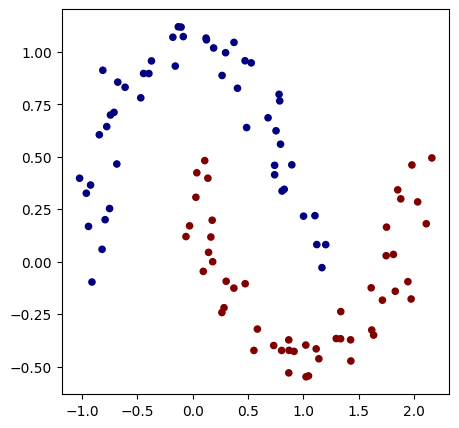

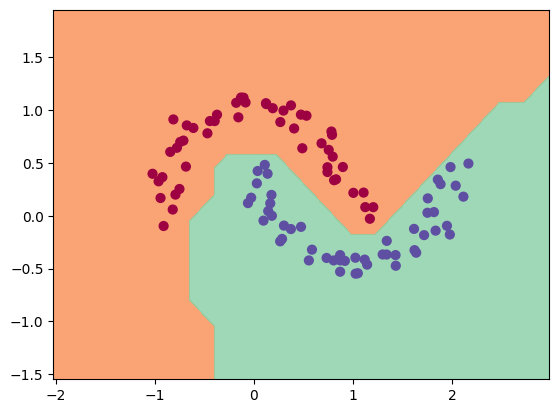

In [229]:
# ======================================================
# IMPORTS
# ======================================================
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP


# ======================================================
# SEED
# ======================================================
np.random.seed(1337)
random.seed(1337)


# ======================================================
# DATASET CREATION
# ======================================================
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=100, noise=0.1)
y = y * 2 - 1  # convert labels to -1 and 1

# visualize dataset
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap='jet')


# ======================================================
# MODEL INITIALIZATION
# ======================================================
model = MLP(2, [16, 16, 1])  # 2-layer neural network
print(model)
print("number of parameters", len(model.parameters()))


# ======================================================
# LOSS FUNCTION
# ======================================================
def loss(batch_size=None):
    # batching
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]

    # forward pass
    inputs = [list(map(Value, xrow)) for xrow in Xb]
    scores = list(map(model, inputs))

    # SVM max-margin loss
    losses = [(1 + -yi * scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))

    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p * p for p in model.parameters()))

    total_loss = data_loss + reg_loss

    # accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]

    return total_loss, sum(accuracy) / len(accuracy)


# initial loss
total_loss, acc = loss()
print(total_loss, acc)


# ======================================================
# TRAINING LOOP (SGD)
# ======================================================
for k in range(100):

    # forward
    total_loss, acc = loss()

    # backward
    model.zero_grad()
    total_loss.backward()

    # update (SGD with decaying LR)
    learning_rate = 1.0 - 0.9 * k / 100
    for p in model.parameters():
        p.data -= learning_rate * p.grad

    # logging
    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100:.1f}%")


# ======================================================
# DECISION BOUNDARY VISUALIZATION
# ======================================================
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))

Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

--- 

one last thing - wanted to show real stuff i.e., how this is implemented in production grade library, like pytorch

what i did: backward pass for tanh in pytorch
- pytorch open source github codebase: https://github.com/pytorch/pytorch
    - hard to find tanh, 2000+ references
        - "meant to be used, not inspected"

    - talks about having to code the tanh backward kernel diff, depdening on CPU v GPU
        - BinaryOpsKernel.cpp

In [ ]:
# done !